<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
═══════════════════════════════════════════════════════════════
V9 — Anomaly Detection Pipeline (Local VSCode / TensorFlow)
Cross-City Transfer Learning zur Anomalie-Erkennung (BA)

Fokus:
  • Statistik-Baseline mit rollender Referenz (vektorisiert)
  • Stationstypen / Demand-Regime
  • Score-Kalibrierung (ECDF)
  • Threshold-Design (station + regime)
  • LSTM-AE mit Last-Step-Scoring (TensorFlow/Keras)
  • Methodischer Vergleich
  • 30-Minuten-Auflösung als Vergleich
═══════════════════════════════════════════════════════════════
"""

Der Fokus ist:

saubere Zielgrößen

kontextuelle Statistik-Baseline

rolling references

stationsspezifische Kalibrierung

AE-Scoring-Korrektur

methodischer Vergleich

optional 30-Minuten-Vergleich

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/BA_Colab/data.zip" "/content/data.zip"
!unzip -q "/content/data.zip" -d "/content"
!rm "/content/data.zip"
!rm -rf "/content/_MACOSX"

Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 1 — Imports, Config, Seeds
# ══════════════════════════════════════════════════════════════
import os
import math
import json
import random
import warnings
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_recall_curve, classification_report
)
from scipy.stats import poisson

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU verfügbar:", len(tf.config.list_physical_devices("GPU")) > 0)

# ══════════════════════════════════════════════════════════════
# 2 — V9 Config
# ══════════════════════════════════════════════════════════════
@dataclass
class V9Config:
    city: str = "Mannheim"
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82

    min_events_per_day: float = 3.0
    rolling_days: int = 56              # 8 Wochen
    min_context_obs: int = 20

    ae_window_size: int = 24            # bei 60min = 24h
    ae_latent_dim: int = 32
    ae_layers: int = 2
    ae_dropout: float = 0.1

    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8

    threshold_quantile_station: float = 0.995
    threshold_quantile_group: float = 0.995

    low_demand_q: float = 0.33
    high_demand_q: float = 0.67

cfg = V9Config()
print(asdict(cfg))

TensorFlow version: 2.19.0
GPU verfügbar: True
{'city': 'Mannheim', 'aggregation_minutes': 60, 'train_ratio': 0.67, 'val_ratio': 0.82, 'min_events_per_day': 3.0, 'rolling_days': 56, 'min_context_obs': 20, 'ae_window_size': 24, 'ae_latent_dim': 32, 'ae_layers': 2, 'ae_dropout': 0.1, 'ae_epochs': 50, 'ae_batch_size': 2048, 'ae_lr': 0.001, 'ae_early_stop': 8, 'threshold_quantile_station': 0.995, 'threshold_quantile_group': 0.995, 'low_demand_q': 0.33, 'high_demand_q': 0.67}


In [3]:
# ══════════════════════════════════════════════════════════════
# 3 — Pfade
# ══════════════════════════════════════════════════════════════
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'

demand_path        = f"{CLEANED_BASE}/demand/{cfg.city}/demand_cleaned.parquet"
geo_path           = f"{CLEANED_BASE}/geo_information/geo_information.parquet"
station_names_path = f"{DATA_BASE}/station_names/station_names.parquet"

RESULTS_DIR = os.path.join(DATA_BASE, "v9_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
# ══════════════════════════════════════════════════════════════
# 4 — Daten laden
# ══════════════════════════════════════════════════════════════
demand = pd.read_parquet(demand_path)
geo = pd.read_parquet(geo_path)
station_names = pd.read_parquet(station_names_path)

station_names = station_names.rename(columns={"id": "station_name_id", "name": "station_name"})
demand["timestamp"] = pd.to_datetime(demand["timestamp"], utc=True)

df_raw = demand.merge(
    station_names[["station_name_id", "station_name"]],
    on="station_name_id", how="left"
).merge(
    geo, on="location_id", how="left"
)

print(f"Rohdaten: {df_raw.shape}")
print(df_raw.head())

Rohdaten: (2547242, 16)
  network_name                 timestamp station_id  station_name_id  \
0     Mannheim 2025-06-12 06:10:00+00:00  378596231            35251   
1     Mannheim 2025-06-12 10:55:00+00:00  378596231            35251   
2     Mannheim 2025-06-12 14:45:00+00:00  378596231            35251   
3     Mannheim 2025-06-12 04:35:00+00:00   27231009            20432   
4     Mannheim 2025-06-12 06:20:00+00:00   27231009            20432   

   location_id  n_lends  n_returns  \
0         7871        0          1   
1         7871        1          0   
2         7871        0          2   
3         7966        1          0   
4         7966        1          0   

                                   station_name continent_name country_name  \
0  Seckenheim - S-Bahnhof  Seckenheim-Hochstätt             EU      Germany   
1  Seckenheim - S-Bahnhof  Seckenheim-Hochstätt             EU      Germany   
2  Seckenheim - S-Bahnhof  Seckenheim-Hochstätt             EU      Germany  

In [5]:
# ══════════════════════════════════════════════════════════════
# 5 — Aggregation auf Stunden oder 30 Minuten
# ══════════════════════════════════════════════════════════════
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)

    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({
            "n_lends": "sum",
            "n_returns": "sum",
            "latitude": "first",
            "longitude": "first"
        })
        .rename(columns={"time_bin": "hour_ts"})
    )

    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()

    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)

    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)

    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg

df = aggregate_station_level(df_raw, minutes=cfg.aggregation_minutes)
print(f"Aggregiert: {df.shape}")
print(df.head())


Aggregiert: (1036182, 22)
  station_id  station_name_id                station_name  location_id  \
0     121376            20229  Lindenhof - Jugendherberge         9856   
1     121376            20229  Lindenhof - Jugendherberge         9856   
2     121376            20229  Lindenhof - Jugendherberge         9856   
3     121376            20229  Lindenhof - Jugendherberge         9856   
4     121376            20229  Lindenhof - Jugendherberge         9856   

                    hour_ts  n_lends  n_returns  latitude  longitude  \
0 2023-03-31 23:00:00+00:00        0          1    49.477      8.464   
1 2023-04-01 09:00:00+00:00        1          0    49.477      8.464   
2 2023-04-01 11:00:00+00:00        2          0    49.477      8.464   
3 2023-04-01 12:00:00+00:00        0          2    49.477      8.464   
4 2023-04-01 13:00:00+00:00        0          1    49.477      8.464   

   total_demand  ...  hour  dow  month  is_weekend      hour_sin  hour_cos  \
0             1  .

In [6]:
# 6 — Aktive Stationen filtern und Demand-Regime bilden
# ══════════════════════════════════════════════════════════════
n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
min_events = int(n_days * cfg.min_events_per_day)

station_volume = df.groupby("station_id")["total_demand"].sum()
active_station_ids = station_volume[station_volume >= min_events].index.tolist()

df = df[df["station_id"].isin(active_station_ids)].copy()
print("Aktive Stationen:", df["station_id"].nunique())

station_profile = (
    df.groupby(["station_id", "station_name"], as_index=False)
      .agg(
          avg_total_demand_h=("total_demand", "mean"),
          avg_lends_h=("n_lends", "mean"),
          avg_returns_h=("n_returns", "mean"),
          latitude=("latitude", "first"),
          longitude=("longitude", "first")
      )
)

q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)

def demand_regime(x):
    if x <= q1:   return "low"
    elif x <= q2:  return "mid"
    return "high"

station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(demand_regime)

df = df.merge(
    station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
    on="station_id", how="left"
)

print(station_profile.head())
print(station_profile["demand_regime"].value_counts())

# ══════════════════════════════════════════════════════════════
# CHECKPOINT 1 — Plausibilitätsprüfung
# ══════════════════════════════════════════════════════════════
print("\n--- CHECKPOINT 1 ---")
print(f"avg_total_demand_h: min={station_profile['avg_total_demand_h'].min():.2f}, "
      f"max={station_profile['avg_total_demand_h'].max():.2f}, "
      f"median={station_profile['avg_total_demand_h'].median():.2f}")
print(f"Regime-Schwellen: low ≤ {q1:.2f}, mid ≤ {q2:.2f}, high > {q2:.2f}")
print(f"net_flow: min={df['net_flow'].min()}, max={df['net_flow'].max()}, "
      f"mean={df['net_flow'].mean():.2f}")

Aktive Stationen: 88
  station_id                  station_name  avg_total_demand_h  avg_lends_h  \
0     121376    Lindenhof - Jugendherberge            2.836174     1.420450   
1  142863936       Hauptbahnhof Mannheim 2            6.090797     3.052060   
2  148606240  A1 - Landgericht/Universität            4.808044     2.425360   
3    1557693    Lindenhof - Johanniskirche            2.069878     1.034455   
4  195402059     Oststadt - Augusta Anlage            1.631069     0.816443   

   avg_returns_h  latitude  longitude demand_regime  
0       1.415723    49.477      8.464           mid  
1       3.038737    49.480      8.471          high  
2       2.382685    49.485      8.463          high  
3       1.035423    49.474      8.466           mid  
4       0.814626    49.478      8.490           low  
demand_regime
mid     31
high    31
low     31
Name: count, dtype: int64

--- CHECKPOINT 1 ---
avg_total_demand_h: min=1.24, max=11.21, median=2.58
Regime-Schwellen: low ≤ 1.96, mi

In [7]:
# ══════════════════════════════════════════════════════════════
# 7 — Train/Val/Test Split
# ══════════════════════════════════════════════════════════════
t_min = df["hour_ts"].min()
t_max = df["hour_ts"].max()
total_h = (t_max - t_min).total_seconds() / 3600

train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))

df_train = df[df["hour_ts"] < train_end].copy()
df_val   = df[(df["hour_ts"] >= train_end) & (df["hour_ts"] < val_end)].copy()
df_test  = df[df["hour_ts"] >= val_end].copy()

print(f"\nTrain: {df_train.shape} | {df_train['hour_ts'].min().date()} – {df_train['hour_ts'].max().date()}")
print(f"Val:   {df_val.shape} | {df_val['hour_ts'].min().date()} – {df_val['hour_ts'].max().date()}")
print(f"Test:  {df_test.shape} | {df_test['hour_ts'].min().date()} – {df_test['hour_ts'].max().date()}")


Train: (716975, 24) | 2023-03-31 – 2025-02-25
Val:   (183064, 24) | 2025-02-25 – 2025-07-30
Test:  (191933, 24) | 2025-07-30 – 2026-02-02


In [8]:
# ══════════════════════════════════════════════════════════════
# 8 — Rolling-kontextuelle Statistik-Baseline (VEKTORISIERT)
#
# Kontext: station × hour × dow
# Zielgrößen: lends, returns, net_flow, total_demand
#
# WICHTIG: Die Original-V9-Version nutzte verschachtelte
# Python-Loops → extrem langsam. Diese Version nutzt
# groupby + expanding/rolling für massive Beschleunigung.
# ══════════════════════════════════════════════════════════════
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]

def add_context_keys(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

df = add_context_keys(df)

def rolling_context_scores_vectorized(
    full_df: pd.DataFrame,
    target: str,
    rolling_days: int = 56,
    min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy()
    x = x.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    mu_col = f"{target}_mu_ctx_roll"
    sd_col = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"

    n_slots = max(rolling_days // 7, 4)

    # Hauptkontext: station × hour × dow
    main_window = n_slots
    main_minp = min(min_obs, main_window)

    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean()
    )
    rolling_std = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0)
    )

    # Fallback 1: station × hour
    fb1_window = n_slots * 2
    fb1_minp = min(min_obs, fb1_window)

    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean()
    )
    fb1_std = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0)
    )

    # Fallback 2: station global
    grouped_s = x.groupby("station_id")[target]
    fb2_mean = grouped_s.transform(
        lambda s: s.shift(1).expanding(min_periods=min_obs).mean()
    )
    fb2_std = grouped_s.transform(
        lambda s: s.shift(1).expanding(min_periods=min_obs).std(ddof=0)
    )

    x[mu_col] = rolling_mean.fillna(fb1_mean).fillna(fb2_mean)
    x[sd_col] = rolling_std.fillna(fb1_std).fillna(fb2_std)
    x[sd_col] = x[sd_col].replace(0, np.nan)

    x[score_col] = (x[target] - x[mu_col]) / x[sd_col]
    return x


print("\nBerechne Rolling-kontextuelle z-Scores (vektorisiert) ...")
for tgt in TARGETS:
    df = rolling_context_scores_vectorized(
        df, target=tgt,
        rolling_days=cfg.rolling_days,
        min_obs=cfg.min_context_obs
    )
    n_valid = df[f"{tgt}_z_ctx_roll"].notna().sum()
    print(f"  {tgt}: {n_valid:,} gültige Scores "
          f"({n_valid / len(df):.1%})")


Berechne Rolling-kontextuelle z-Scores (vektorisiert) ...
  n_lends: 1,072,714 gültige Scores (98.2%)
  n_returns: 1,067,501 gültige Scores (97.8%)
  net_flow: 1,085,117 gültige Scores (99.4%)
  total_demand: 1,071,190 gültige Scores (98.1%)


In [9]:
# ══════════════════════════════════════════════════════════════
# 9 — Upper / Lower Scores
# ══════════════════════════════════════════════════════════════
for tgt in TARGETS:
    zc = f"{tgt}_z_ctx_roll"
    df[f"{tgt}_score_upper"] = df[zc]
    df[f"{tgt}_score_lower"] = -df[zc]

# ══════════════════════════════════════════════════════════════
# 10 — Rolling Poisson Tail Scores (VEKTORISIERT)
#      Nur für count-artige Targets
# ══════════════════════════════════════════════════════════════
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_rolling_poisson_scores_vectorized(
    full_df: pd.DataFrame,
    target: str,
    rolling_days: int = 56,
    min_obs: int = 20
) -> pd.DataFrame:
    """
    Vektorisierte Poisson-Tail-Scores. Nutzt die rolling lambda
    aus dem Kontextmittel und berechnet vektorisiert die
    Survival-Funktion.
    """
    x = full_df.copy()
    x = x.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    lam_col = f"{target}_lambda_ctx_roll"
    score_col = f"{target}_poisson_upper_score"

    # Lambda aus dem bereits berechneten rolling mean
    mu_col = f"{target}_mu_ctx_roll"
    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden (Zelle 8)")

    x[lam_col] = x[mu_col].clip(lower=1e-6)

    # Vektorisierte Poisson-Survival
    vals = x[target].values
    lams = x[lam_col].values

    # poisson.sf ist vektorisiert für arrays
    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score = -np.log10(np.clip(tail_p, 1e-12, None))

    # NaN wo lambda NaN ist
    mask_nan = np.isnan(lams)
    score[mask_nan] = np.nan

    x[score_col] = score
    return x


print("\nBerechne Poisson-Tail-Scores (vektorisiert) ...")
for tgt in COUNT_TARGETS:
    df = add_rolling_poisson_scores_vectorized(
        df, target=tgt,
        rolling_days=cfg.rolling_days,
        min_obs=cfg.min_context_obs
    )
    n_valid = df[f"{tgt}_poisson_upper_score"].notna().sum()
    print(f"  {tgt}: {n_valid:,} gültige Scores")


# ══════════════════════════════════════════════════════════════
# 10b — Rolling Poisson Lower Tail Scores
#       Für ungewöhnlich niedrige Count-Werte
# ══════════════════════════════════════════════════════════════
def add_rolling_poisson_lower_scores_vectorized(
    full_df: pd.DataFrame,
    target: str
) -> pd.DataFrame:
    x = full_df.copy()
    x = x.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    lam_col = f"{target}_lambda_ctx_roll"
    mu_col = f"{target}_mu_ctx_roll"
    score_col = f"{target}_poisson_lower_score"

    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")

    x[lam_col] = x[mu_col].clip(lower=1e-6)

    vals = x[target].values.astype(float)
    lams = x[lam_col].values.astype(float)

    with np.errstate(divide="ignore", invalid="ignore"):
        # P(X <= observed)
        tail_p = poisson.cdf(vals, lams)
        score = -np.log10(np.clip(tail_p, 1e-12, None))

    score[np.isnan(lams)] = np.nan
    x[score_col] = score
    return x


print("\nBerechne Poisson-Lower-Tail-Scores ...")
for tgt in COUNT_TARGETS:
    df = add_rolling_poisson_lower_scores_vectorized(df, target=tgt)
    n_valid = df[f"{tgt}_poisson_lower_score"].notna().sum()
    print(f"  {tgt}: {n_valid:,} gültige Scores")


Berechne Poisson-Tail-Scores (vektorisiert) ...
  n_lends: 1,090,212 gültige Scores
  n_returns: 1,090,212 gültige Scores
  total_demand: 1,090,212 gültige Scores

Berechne Poisson-Lower-Tail-Scores ...
  n_lends: 1,090,212 gültige Scores
  n_returns: 1,090,212 gültige Scores
  total_demand: 1,090,212 gültige Scores



--- CHECKPOINT 2 ---


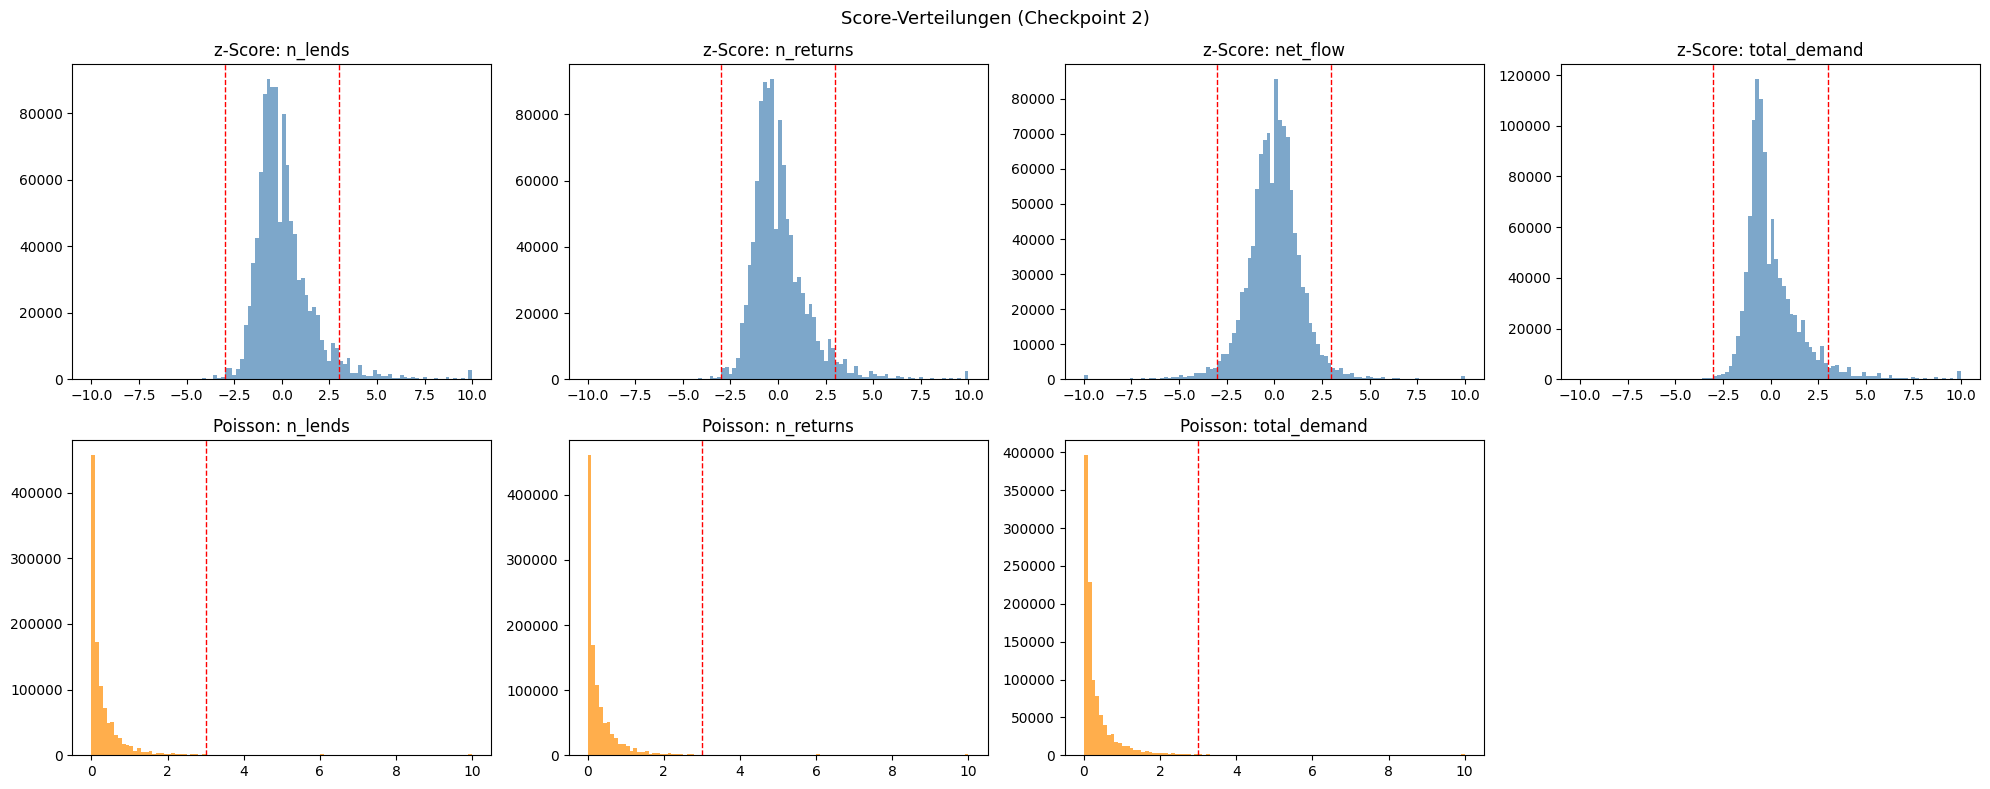

Plot gespeichert: /content/drive/MyDrive/BA_Colab/data/v9_results/checkpoint2_score_distributions.png


In [10]:
# ══════════════════════════════════════════════════════════════
# CHECKPOINT 2 — Score-Verteilungen prüfen
# ══════════════════════════════════════════════════════════════
print("\n--- CHECKPOINT 2 ---")
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Score-Verteilungen (Checkpoint 2)", fontsize=13)

for i, tgt in enumerate(TARGETS):
    col = f"{tgt}_z_ctx_roll"
    vals = df[col].dropna()
    axes[0, i].hist(vals.clip(-10, 10), bins=100, alpha=0.7, color="steelblue")
    axes[0, i].set_title(f"z-Score: {tgt}")
    axes[0, i].axvline(3, color="red", ls="--", lw=1)
    axes[0, i].axvline(-3, color="red", ls="--", lw=1)

for i, tgt in enumerate(COUNT_TARGETS):
    col = f"{tgt}_poisson_upper_score"
    vals = df[col].dropna()
    axes[1, i].hist(vals.clip(0, 10), bins=100, alpha=0.7, color="darkorange")
    axes[1, i].set_title(f"Poisson: {tgt}")
    axes[1, i].axvline(3, color="red", ls="--", lw=1)

axes[1, 3].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "checkpoint2_score_distributions.png"), dpi=150)
plt.show()
print(f"Plot gespeichert: {RESULTS_DIR}/checkpoint2_score_distributions.png")

In [11]:
# ══════════════════════════════════════════════════════════════
# 11 — Labels für Evaluation
#
# Strategie: Konsens-Label aus z-Score + Poisson.
# Ein Zeitpunkt ist "anomal" wenn:
#   (a) z_ctx_roll(total_demand) > 3  ODER
#   (b) poisson_upper_score(total_demand) > 3
# UND total_demand >= 5 (Mindest-Absolut-Filter)
#
# "grauzone": z > 2 ODER poisson > 2 (aber nicht anomal)
# ══════════════════════════════════════════════════════════════
def build_eval_labels(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    z_col = "total_demand_z_ctx_roll"
    p_col = "total_demand_poisson_upper_score"

    has_z = z_col in y.columns and y[z_col].notna().any()
    has_p = p_col in y.columns and y[p_col].notna().any()

    if not has_z and not has_p:
        print("⚠️  Keine Scores verfügbar für Labeling.")
        return y

    # Anomal: starke Abweichung in mindestens einer Methode + Absolutfilter
    cond_anomal = pd.Series(False, index=y.index)
    if has_z:
        cond_anomal |= (y[z_col].abs() > 3)
    if has_p:
        cond_anomal |= (y[p_col] > 3)
    cond_anomal &= (y["total_demand"] >= 5)

    # Grauzone: moderate Abweichung
    cond_grau = pd.Series(False, index=y.index)
    if has_z:
        cond_grau |= (y[z_col].abs() > 2)
    if has_p:
        cond_grau |= (y[p_col] > 2)
    cond_grau &= ~cond_anomal

    y.loc[cond_grau, "label_eval"] = "grauzone"
    y.loc[cond_anomal, "label_eval"] = "anomal"

    return y

df = build_eval_labels(df)
print("\nLabel-Verteilung:")
print(df["label_eval"].value_counts())
print(f"Anomalie-Rate: {(df['label_eval'] == 'anomal').mean():.4f}")

# Splits mit Labels aktualisieren
df_train = df[df["hour_ts"] < train_end].copy()
df_val   = df[(df["hour_ts"] >= train_end) & (df["hour_ts"] < val_end)].copy()
df_test  = df[df["hour_ts"] >= val_end].copy()


Label-Verteilung:
label_eval
normal      970087
grauzone     78748
anomal       43137
Name: count, dtype: int64
Anomalie-Rate: 0.0395


In [12]:
# ══════════════════════════════════════════════════════════════
# 12 — Score-Kalibrierung pro Station (ECDF)
# ══════════════════════════════════════════════════════════════
def percentile_score(train_vals: np.ndarray, values: np.ndarray) -> np.ndarray:
    """Train-only ECDF: Percentil-Rang relativ zur Trainingsverteilung."""
    train_vals = np.asarray(train_vals, dtype=float)
    values = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]

    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)

    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)


def calibrate_scores_by_station(
    full_df: pd.DataFrame,
    train_mask: pd.Series,
    raw_score_cols: List[str]
) -> pd.DataFrame:
    x = full_df.copy()

    for col in raw_score_cols:
        if col not in x.columns:
            print(f"⚠️ Übersprungen, Spalte fehlt: {col}")
            continue

        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan

        for sid, grp in x.groupby("station_id", sort=False):
            idx_all = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]

            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals = x.loc[idx_all, col].to_numpy(dtype=float)

            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)

    return x

In [13]:
raw_score_cols = []
for tgt in TARGETS:
    raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
for tgt in COUNT_TARGETS:
    raw_score_cols += [
        f"{tgt}_poisson_upper_score",
        f"{tgt}_poisson_lower_score"
    ]

In [14]:
train_mask_full = df["hour_ts"] < train_end
df = calibrate_scores_by_station(df, train_mask_full, raw_score_cols)

In [15]:
# ══════════════════════════════════════════════════════════════
# 12b — Verbesserte Evaluationslabels (stationskalibriert, high + low)
# ══════════════════════════════════════════════════════════════
def build_eval_labels_calibrated(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    # Kalibrierte Scores für total_demand
    z_up   = "total_demand_score_upper_pct_station"
    z_low  = "total_demand_score_lower_pct_station"
    p_up   = "total_demand_poisson_upper_score_pct_station"
    p_low  = "total_demand_poisson_lower_score_pct_station"

    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten für Labeling: {missing}")

    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]

    # Dynamischer Mindestfilter:
    # verhindert triviale low-demand-Treffer bei sehr kleinen Counts
    abs_min_high = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)

    # -------------------------
    # HIGH anomalies
    # -------------------------
    high_strong = (
        (y[z_up] >= 0.999) |
        (y[p_up] >= 0.999)
    ) & (td >= abs_min_high)

    high_consensus = (
        (y[z_up] >= 0.995) &
        (y[p_up] >= 0.995)
    ) & (td >= abs_min_high)

    cond_high = high_strong | high_consensus

    # -------------------------
    # LOW anomalies
    # -------------------------
    # Low nur sinnvoll, wenn die erwartete Nachfrage nicht fast null ist
    low_possible = mu >= abs_min_low_ref

    low_strong = (
        (y[z_low] >= 0.999) |
        (y[p_low] >= 0.999)
    ) & low_possible

    low_consensus = (
        (y[z_low] >= 0.995) &
        (y[p_low] >= 0.995)
    ) & low_possible

    cond_low = (low_strong | low_consensus)

    # Konflikte vermeiden
    cond_low = cond_low & ~cond_high

    # -------------------------
    # Grauzonen
    # -------------------------
    gray_high = (
        (
            (y[z_up] >= 0.98) |
            (y[p_up] >= 0.98)
        ) &
        ~cond_high &
        (td >= np.maximum(4, np.ceil(mu + 1)).fillna(4))
    )

    gray_low = (
        (
            (y[z_low] >= 0.98) |
            (y[p_low] >= 0.98)
        ) &
        ~cond_low &
        ~cond_high &
        low_possible
    )

    y.loc[gray_high, "label_eval"] = "grauzone_high"
    y.loc[gray_low, "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low, "label_eval"] = "anomal_low"

    return y


# WICHTIG:
# Diese Zelle nach der stationsspezifischen Kalibrierung ausführen.
df = build_eval_labels_calibrated(df)

print("\nNeue Label-Verteilung:")
print(df["label_eval"].value_counts())
print("\nAnomalie-Raten:")
print("anomal_high:", (df["label_eval"] == "anomal_high").mean().round(4))
print("anomal_low: ", (df["label_eval"] == "anomal_low").mean().round(4))
print("gesamt anomal:", df["label_eval"].isin(["anomal_high", "anomal_low"]).mean().round(4))

# Splits neu ziehen
df_train = df[df["hour_ts"] < train_end].copy()
df_val   = df[(df["hour_ts"] >= train_end) & (df["hour_ts"] < val_end)].copy()
df_test  = df[df["hour_ts"] >= val_end].copy()


Neue Label-Verteilung:
label_eval
normal           1056131
grauzone_high      26982
anomal_high         4201
grauzone_low        4019
anomal_low           639
Name: count, dtype: int64

Anomalie-Raten:
anomal_high: 0.0038
anomal_low:  0.0006
gesamt anomal: 0.0044


In [16]:
pct_cols = [c for c in df.columns if c.endswith("_pct_station")]
print("Anzahl pct-Spalten:", len(pct_cols))
print(pct_cols[:10])

Anzahl pct-Spalten: 14
['n_lends_score_upper_pct_station', 'n_lends_score_lower_pct_station', 'n_returns_score_upper_pct_station', 'n_returns_score_lower_pct_station', 'net_flow_score_upper_pct_station', 'net_flow_score_lower_pct_station', 'total_demand_score_upper_pct_station', 'total_demand_score_lower_pct_station', 'n_lends_poisson_upper_score_pct_station', 'n_lends_poisson_lower_score_pct_station']


In [17]:
# ══════════════════════════════════════════════════════════════
# 13 — Stations- und Regime-Thresholds
# ══════════════════════════════════════════════════════════════
def build_station_thresholds(x: pd.DataFrame, score_col_pct: str, q: float = 0.995) -> pd.DataFrame:
    tmp = x[x["hour_ts"] < train_end].copy()
    thr = (
        tmp.groupby("station_id")[score_col_pct]
           .quantile(q)
           .reset_index()
           .rename(columns={score_col_pct: f"{score_col_pct}_thr_station"})
    )
    return thr


def build_regime_thresholds(x: pd.DataFrame, score_col_pct: str, q: float = 0.995) -> pd.DataFrame:
    tmp = x[x["hour_ts"] < train_end].copy()
    thr = (
        tmp.groupby("demand_regime")[score_col_pct]
           .quantile(q)
           .reset_index()
           .rename(columns={score_col_pct: f"{score_col_pct}_thr_regime"})
    )
    return thr


for col in pct_cols:
    thr_station = build_station_thresholds(df, col, q=cfg.threshold_quantile_station)
    thr_regime  = build_regime_thresholds(df, col, q=cfg.threshold_quantile_group)

    df = df.merge(thr_station, on="station_id", how="left")
    df = df.merge(thr_regime, on="demand_regime", how="left")

    df[f"{col}_pred_station"] = (df[col] >= df[f"{col}_thr_station"]).astype(int)
    df[f"{col}_pred_regime"]  = (df[col] >= df[f"{col}_thr_regime"]).astype(int)

In [18]:
# ══════════════════════════════════════════════════════════════
# CHECKPOINT 3 — Threshold-Plausibilität
# ══════════════════════════════════════════════════════════════
print("\n--- CHECKPOINT 3 ---")
example_col = "total_demand_score_upper_pct_station"
if f"{example_col}_thr_station" in df.columns:
    thr_by_regime = (
        df[df["hour_ts"] < train_end]
        .groupby("demand_regime")[f"{example_col}_thr_station"]
        .describe()
    )
    print(f"Thresholds für '{example_col}' nach Regime:")
    print(thr_by_regime.round(4))


--- CHECKPOINT 3 ---
Thresholds für 'total_demand_score_upper_pct_station' nach Regime:
                  count    mean     std     min    25%  50%  75%  max
demand_regime                                                        
high           313743.0  0.9995  0.0008  0.9970  0.999  1.0  1.0  1.0
low            125962.0  1.0000  0.0000  1.0000  1.000  1.0  1.0  1.0
mid            277270.0  0.9999  0.0002  0.9991  1.000  1.0  1.0  1.0


In [19]:
# ══════════════════════════════════════════════════════════════
# Debug 1 — Verwendete Stationen prüfen
# ══════════════════════════════════════════════════════════════

stations_used = (
    df.groupby(["station_id", "station_name"], as_index=False)
      .agg(
          n_rows=("hour_ts", "size"),
          min_ts=("hour_ts", "min"),
          max_ts=("hour_ts", "max"),
          avg_total_demand_h=("total_demand", "mean"),
          avg_lends_h=("n_lends", "mean"),
          avg_returns_h=("n_returns", "mean"),
          regime=("demand_regime", "first")
      )
      .sort_values("avg_total_demand_h")
      .reset_index(drop=True)
)

print("Anzahl verwendeter Stationen:", stations_used["station_id"].nunique())
display(stations_used)

Anzahl verwendeter Stationen: 88


,station_id,station_name,n_rows,min_ts,max_ts,avg_total_demand_h,avg_lends_h,avg_returns_h,regime
0,24559076,Herzogenried - Sandgewann,3307,2023-04-01 14:00:00+00:00,2026-02-02 20:00:00+00:00,1.237980,0.616269,0.621712,low
1,38930122,Käfertal Mitte,3025,2023-04-01 02:00:00+00:00,2026-02-02 21:00:00+00:00,1.256860,0.628760,0.628099,low
2,378596026,Seckenheim - Wasserturm / Kapellenplatz,2551,2024-03-26 15:00:00+00:00,2026-02-02 19:00:00+00:00,1.282634,0.635437,0.647197,low
3,24559100,Neuhermsheim - Dragonerweg,2550,2023-04-01 02:00:00+00:00,2026-02-02 17:00:00+00:00,1.286667,0.640000,0.646667,low
4,38930150,Franklin - George-Washington-Straße,2750,2023-04-03 11:00:00+00:00,2026-02-02 17:00:00+00:00,1.290182,0.645818,0.644364,low
...,...,...,...,...,...,...,...,...,...
88,339468,Universität Mensa,13328,2023-04-01 04:00:00+00:00,2026-02-02 16:00:00+00:00,7.088010,3.541717,3.546294,high
89,339472,A5 - Universität West,19662,2023-03-31 23:00:00+00:00,2026-02-02 23:00:00+00:00,8.844726,4.439630,4.405096,high
90,339475,Hauptbahnhof Mannheim 1,10752,2023-03-31 23:00:00+00:00,2023-12-13 16:00:00+00:00,9.634487,4.889137,4.745350,high
91,660951,Universität Schloss,14770,2023-04-01 00:00:00+00:00,2026-02-02 20:00:00+00:00,11.130873,5.566892,5.563981,high


In [20]:
print("df station_id dtype:           ", df["station_id"].dtype)
print("station_profile station_id dtype:", station_profile["station_id"].dtype)

ids_df = set(df["station_id"].dropna().unique())
ids_profile = set(station_profile["station_id"].dropna().unique())

print("IDs in df:", len(ids_df))
print("IDs in station_profile:", len(ids_profile))
print("In profile aber nicht in df:", len(ids_profile - ids_df))
print("In df aber nicht in profile:", len(ids_df - ids_profile))

print("Beispiele nur in profile:", list(sorted(ids_profile - ids_df))[:10])
print("Beispiele nur in df:", list(sorted(ids_df - ids_profile))[:10])

df station_id dtype:            object
station_profile station_id dtype: object
IDs in df: 88
IDs in station_profile: 88
In profile aber nicht in df: 0
In df aber nicht in profile: 0
Beispiele nur in profile: []
Beispiele nur in df: []


In [21]:
# ══════════════════════════════════════════════════════════════
# Debug 2 — Repräsentative Stationen direkt aus df bestimmen
# ══════════════════════════════════════════════════════════════

stations_used = stations_used.sort_values("avg_total_demand_h").reset_index(drop=True)

low_station = stations_used.iloc[0]
median_station = stations_used.iloc[len(stations_used) // 2]
high_station = stations_used.iloc[-1]

selected_stations = pd.DataFrame([low_station, median_station, high_station]).copy()
selected_stations["role"] = ["low", "median", "high"]

display(selected_stations[[
    "role", "station_id", "station_name",
    "avg_total_demand_h", "avg_lends_h", "avg_returns_h",
    "n_rows", "min_ts", "max_ts", "regime"
]])

,role,station_id,station_name,avg_total_demand_h,avg_lends_h,avg_returns_h,n_rows,min_ts,max_ts,regime
0,low,24559076,Herzogenried - Sandgewann,1.237980,0.616269,0.621712,3307,2023-04-01 14:00:00+00:00,2026-02-02 20:00:00+00:00,low
46,median,28450242,Lindenhof - Hanns-Glückstein-Park,2.583512,1.296799,1.286713,12591,2023-04-01 06:00:00+00:00,2026-02-02 22:00:00+00:00,mid
92,high,339475,Hauptbahnhof Mannheim,11.209693,5.671277,5.538416,34126,2023-12-13 16:00:00+00:00,2026-02-02 23:00:00+00:00,high


In [22]:
selected_ids = selected_stations["station_id"].tolist()

check_test = (
    df_test[df_test["station_id"].isin(selected_ids)]
    .groupby("station_id", as_index=False)
    .agg(
        n_rows_test=("hour_ts", "size"),
        min_ts_test=("hour_ts", "min"),
        max_ts_test=("hour_ts", "max")
    )
)

display(check_test)

,station_id,n_rows_test,min_ts_test,max_ts_test
0,24559076,600,2025-07-31 03:00:00+00:00,2026-02-02 20:00:00+00:00
1,28450242,2140,2025-07-31 05:00:00+00:00,2026-02-02 22:00:00+00:00
2,339475,8340,2025-07-30 22:00:00+00:00,2026-02-02 23:00:00+00:00


low: station_id=24559076, rows=3307
median: station_id=28450242, rows=12591
high: station_id=339475, rows=44878


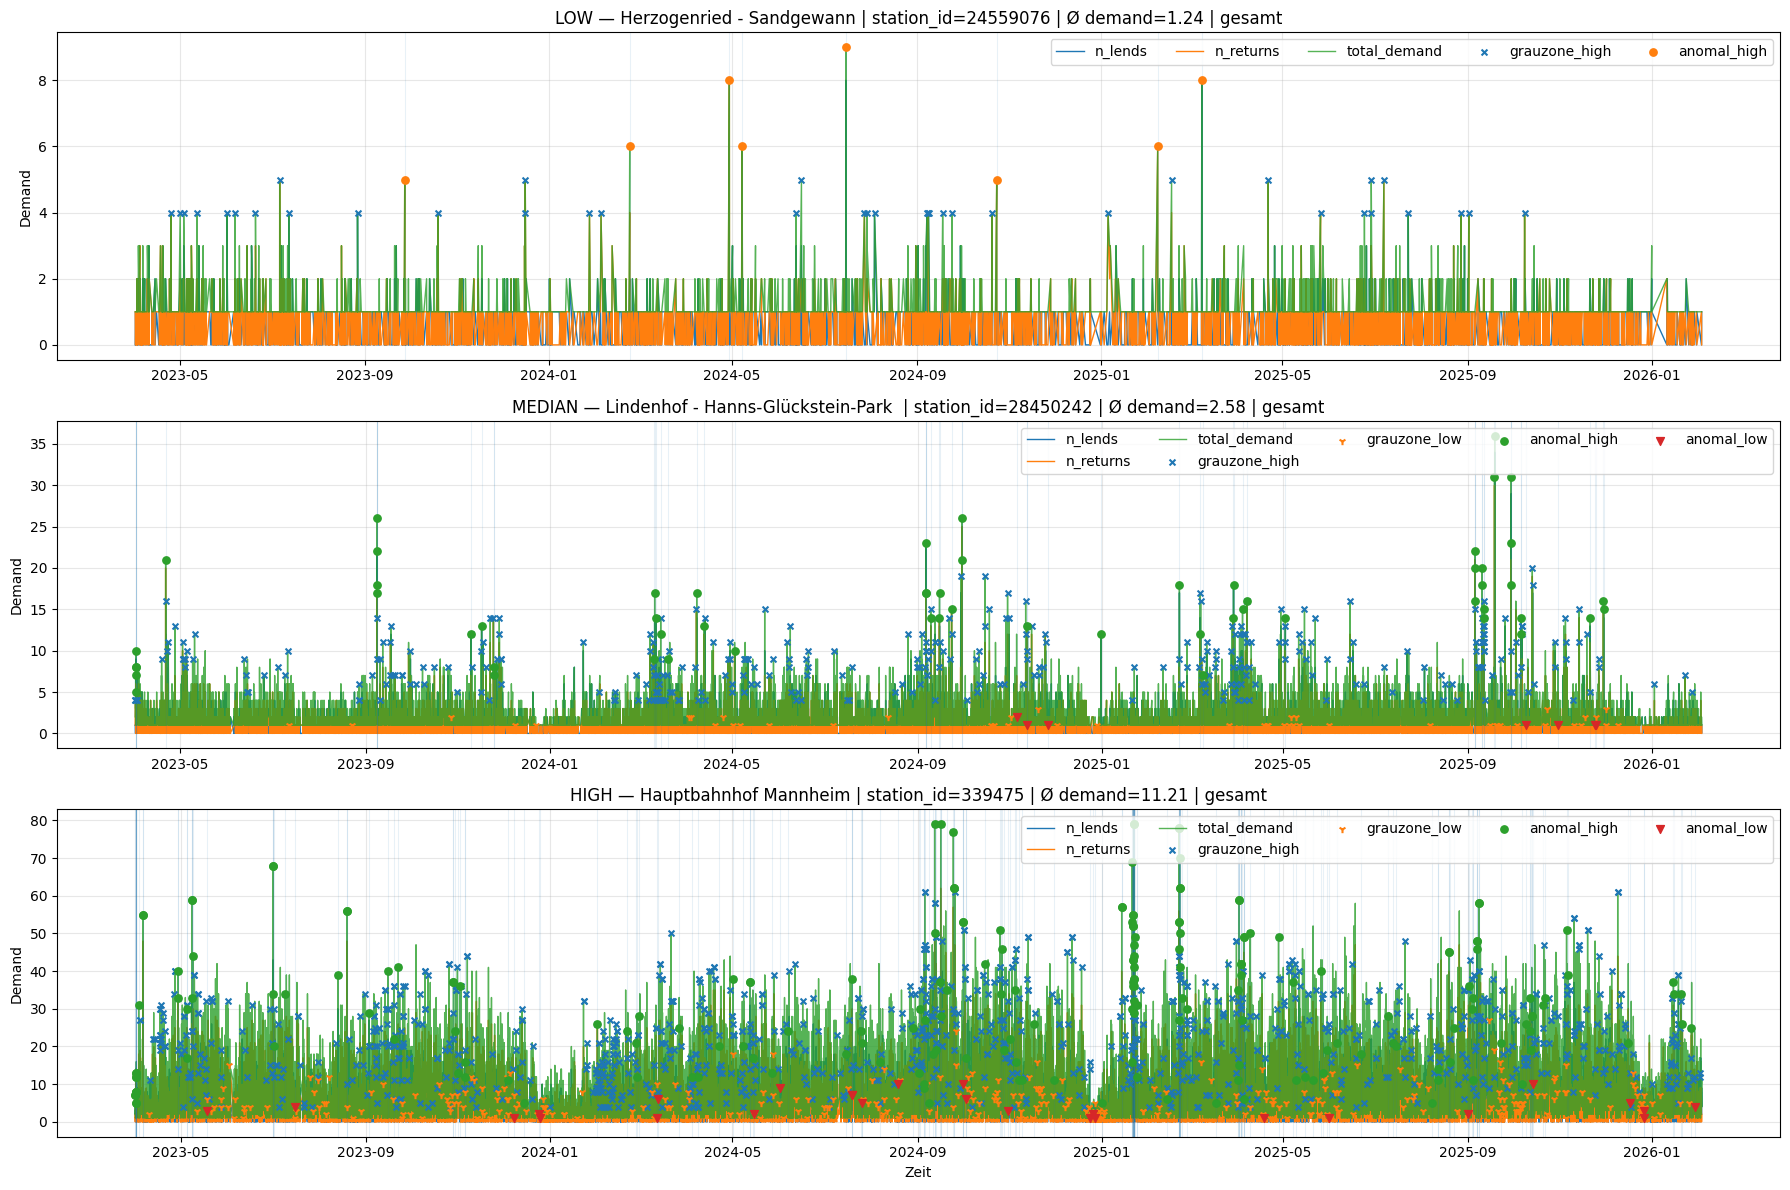

low: station_id=24559076, rows=600
median: station_id=28450242, rows=2140
high: station_id=339475, rows=8340


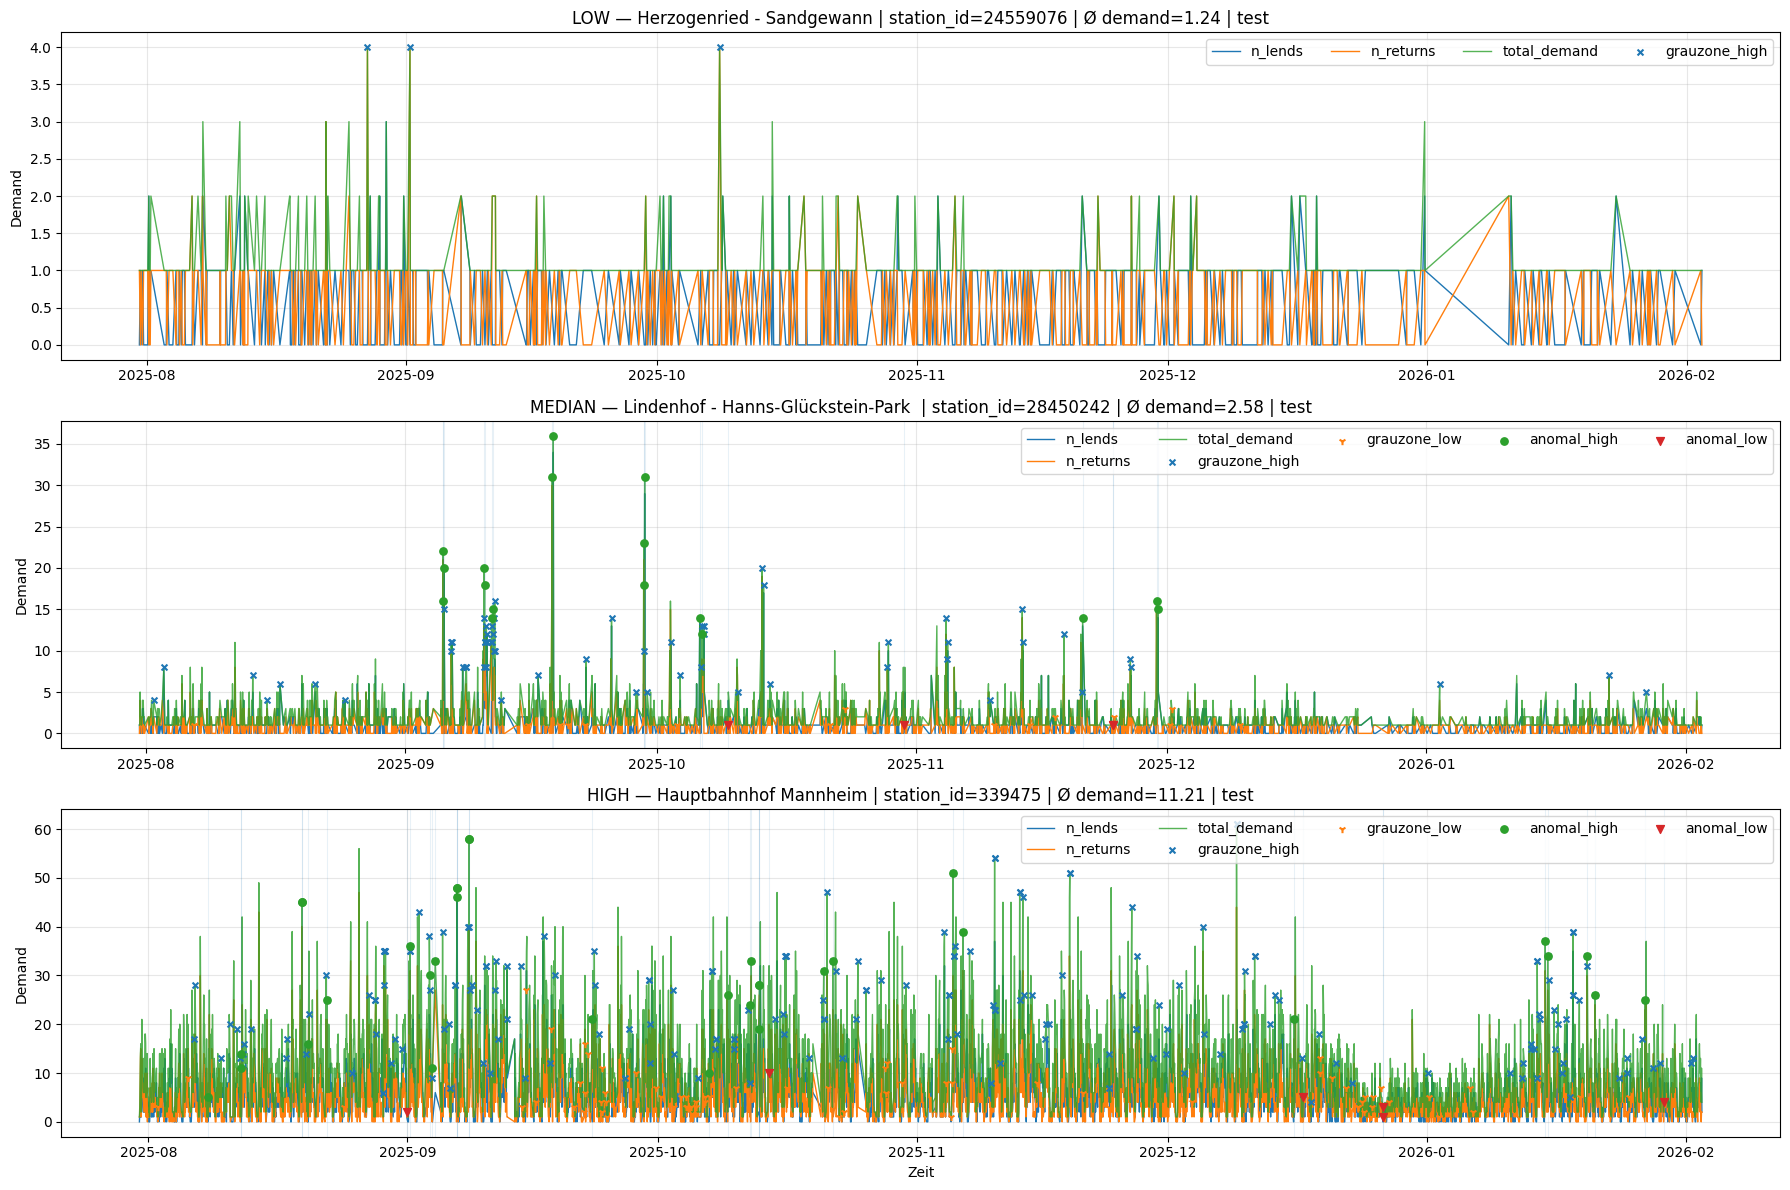

In [23]:
# ══════════════════════════════════════════════════════════════
# 14 — Robuste Fallstudien-Plots
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

def plot_selected_stations(data: pd.DataFrame, selected_stations: pd.DataFrame, label_col="label_eval", title_suffix=""):
    fig, axes = plt.subplots(len(selected_stations), 1, figsize=(18, 4 * len(selected_stations)), sharex=False)

    if len(selected_stations) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, selected_stations.iterrows()):
        sid = row["station_id"]
        role = row["role"]
        sname = row["station_name"]

        sub = data[data["station_id"] == sid].sort_values("hour_ts").copy()

        print(f"{role}: station_id={sid}, rows={len(sub)}")

        if sub.empty:
            ax.set_title(f"{role.upper()} — {sname} (station_id={sid}) — KEINE DATEN")
            ax.grid(True, alpha=0.3)
            continue

        ax.plot(sub["hour_ts"], sub["n_lends"], label="n_lends", linewidth=1.0)
        ax.plot(sub["hour_ts"], sub["n_returns"], label="n_returns", linewidth=1.0)
        ax.plot(sub["hour_ts"], sub["total_demand"], label="total_demand", linewidth=1.0, alpha=0.8)

        if label_col in sub.columns:
          anom_high = sub[sub[label_col] == "anomal_high"]
          anom_low  = sub[sub[label_col] == "anomal_low"]
          grau_high = sub[sub[label_col] == "grauzone_high"]
          grau_low  = sub[sub[label_col] == "grauzone_low"]

          if not grau_high.empty:
              ax.scatter(grau_high["hour_ts"], grau_high["total_demand"],
                        marker="x", s=18, label="grauzone_high", zorder=4)

          if not grau_low.empty:
              ax.scatter(grau_low["hour_ts"], grau_low["total_demand"],
                        marker="1", s=28, label="grauzone_low", zorder=4)

          if not anom_high.empty:
              ax.scatter(anom_high["hour_ts"], anom_high["total_demand"],
                        marker="o", s=28, label="anomal_high", zorder=5)
              for ts in anom_high["hour_ts"]:
                  ax.axvline(ts, alpha=0.10, linewidth=0.8)

          if not anom_low.empty:
              ax.scatter(anom_low["hour_ts"], anom_low["total_demand"],
                        marker="v", s=32, label="anomal_low", zorder=5)
              for ts in anom_low["hour_ts"]:
                  ax.axvline(ts, alpha=0.10, linewidth=0.8)

        ax.set_title(
            f"{role.upper()} — {sname} | station_id={sid} | "
            f"Ø demand={row['avg_total_demand_h']:.2f} | {title_suffix}"
        )
        ax.set_ylabel("Demand")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", ncol=5)

    axes[-1].set_xlabel("Zeit")
    plt.tight_layout()
    plt.show()


# Gesamt
plot_selected_stations(df, selected_stations, title_suffix="gesamt")

# Test
plot_selected_stations(df_test, selected_stations, title_suffix="test")

In [24]:
# ══════════════════════════════════════════════════════════════
# 14 — AE-Features (saubere Version ohne Lag-Leckage)
# ══════════════════════════════════════════════════════════════
AE_FEATURES = [
    "n_lends",
    "n_returns",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "is_weekend"
]

df_ae = df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
df_ae = df_ae.dropna(subset=AE_FEATURES).copy()

print(f"\nAE-Daten: {df_ae.shape}")
print(f"AE-Features ({len(AE_FEATURES)}): {AE_FEATURES}")


AE-Daten: (1091972, 126)
AE-Features (9): ['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']


In [25]:
# ══════════════════════════════════════════════════════════════
# 15 — Scaler fitten (nur auf Train)
# ══════════════════════════════════════════════════════════════
scaler = StandardScaler()
train_mask_ae = df_ae["hour_ts"] < train_end

scaler.fit(df_ae.loc[train_mask_ae, AE_FEATURES])

df_ae_scaled = df_ae.copy()
df_ae_scaled[AE_FEATURES] = scaler.transform(df_ae[AE_FEATURES])

print("Scaler fitted on train only.")
print(f"Train-Zeilen für Scaler: {train_mask_ae.sum():,}")
print(f"Features: {len(AE_FEATURES)}")

Scaler fitted on train only.
Train-Zeilen für Scaler: 716,975
Features: 9


In [26]:
# ══════════════════════════════════════════════════════════════
# 16 — Schneller Sequenzbuilder
# ══════════════════════════════════════════════════════════════
from numpy.lib.stride_tricks import sliding_window_view

def make_sequences_fast(
    x: pd.DataFrame,
    feature_cols: List[str],
    window_size: int,
    label_col: Optional[str] = None,
    require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame, Optional[np.ndarray]]:
    X_parts = []
    meta_parts = []
    y_parts = []

    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)

        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)

        # sliding_window_view über Zeitachse
        # Ergebnis typischerweise: (n-window+1, n_features, window_size)
        win = sliding_window_view(vals, window_shape=window_size, axis=0)
        win = np.moveaxis(win, -1, 1)   # -> (n_windows, window_size, n_features)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs = np.diff(ts_int)

            step_ok = (diffs == expected_ns).astype(np.int8)

            if window_size > 1:
                ok_sums = np.convolve(
                    step_ok,
                    np.ones(window_size - 1, dtype=np.int32),
                    mode="valid"
                )
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]

        X_parts.append(win[valid_mask])
        meta_parts.append(g.iloc[end_indices].copy())

        if label_col is not None:
            y_parts.append(g.iloc[end_indices][label_col].to_numpy())

    if X_parts:
        X = np.concatenate(X_parts, axis=0).astype(np.float32)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
    else:
        X = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()

    if label_col is not None:
        y = np.concatenate(y_parts, axis=0) if y_parts else np.array([], dtype=object)
    else:
        y = None

    return X, meta, y

In [27]:
# ══════════════════════════════════════════════════════════════
# 16b — Sequenzen für Train / Val / Test erzeugen
#       Training möglichst nur auf normalen Fenstern
# ══════════════════════════════════════════════════════════════
label_col_for_ae = "label_eval" if "label_eval" in df_ae_scaled.columns else None

X_all, meta_all, y_all = make_sequences_fast(
    df_ae_scaled,
    feature_cols=AE_FEATURES,
    window_size=cfg.ae_window_size,
    label_col=label_col_for_ae,
    require_contiguous=False,   # <- testweise
    agg_minutes=cfg.aggregation_minutes
)

print("Sequenzen gesamt:", X_all.shape)
print("Meta gesamt:", meta_all.shape)

meta_all["split"] = np.where(
    meta_all["hour_ts"] < train_end, "train",
    np.where(meta_all["hour_ts"] < val_end, "val", "test")
)

train_seq_mask = meta_all["split"] == "train"
val_seq_mask   = meta_all["split"] == "val"
test_seq_mask  = meta_all["split"] == "test"

# Für das AE-Training möglichst nur normale Fenster verwenden
if label_col_for_ae is not None:
    normal_train_mask = train_seq_mask & (meta_all["label_eval"] == "normal")
    normal_val_mask   = val_seq_mask & (meta_all["label_eval"] == "normal")
else:
    normal_train_mask = train_seq_mask
    normal_val_mask   = val_seq_mask

X_train = X_all[normal_train_mask.values]
X_val   = X_all[normal_val_mask.values]
X_test  = X_all[test_seq_mask.values]

meta_train = meta_all.loc[normal_train_mask].reset_index(drop=True)
meta_val   = meta_all.loc[normal_val_mask].reset_index(drop=True)
meta_test  = meta_all.loc[test_seq_mask].reset_index(drop=True)

print(f"X_train (normal only): {X_train.shape}")
print(f"X_val   (normal only): {X_val.shape}")
print(f"X_test:               {X_test.shape}")

if label_col_for_ae is not None:
    print("\nLabel-Verteilung über alle Sequenz-Endpunkte:")
    print(meta_all["label_eval"].value_counts(dropna=False))

Sequenzen gesamt: (1089948, 24, 9)
Meta gesamt: (1089948, 126)
X_train (normal only): (692227, 24, 9)
X_val   (normal only): (176081, 24, 9)
X_test:               (191933, 24, 9)

Label-Verteilung über alle Sequenz-Endpunkte:
label_eval
normal           1054406
grauzone_high      26887
grauzone_low        4018
anomal_high         3998
anomal_low           639
Name: count, dtype: int64


In [28]:
# ══════════════════════════════════════════════════════════════
# 17 — LSTM Autoencoder (TensorFlow/Keras)
# ══════════════════════════════════════════════════════════════
def build_lstm_autoencoder(
    n_features: int,
    window_size: int,
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1
) -> keras.Model:
    """
    Sequence-to-Sequence LSTM Autoencoder.
    Rekonstruiert die gesamte Sequenz.
    Der spätere Anomalie-Score kann gezielt auf dem letzten
    Zeitschritt berechnet werden.
    """
    inputs = keras.Input(shape=(window_size, n_features), name="encoder_input")

    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        x = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"encoder_lstm_{i+1}"
        )(x)

    latent = x

    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)

    for i in range(n_layers):
        x = layers.LSTM(
            latent_dim,
            return_sequences=True,
            dropout=dropout,
            name=f"decoder_lstm_{i+1}"
        )(x)

    outputs = layers.TimeDistributed(
        layers.Dense(n_features),
        name="output_dense"
    )(x)

    model = keras.Model(inputs, outputs, name="lstm_autoencoder")
    return model


def train_autoencoder(
    model: keras.Model,
    X_train: np.ndarray,
    X_val: np.ndarray,
    cfg: V9Config
):
    """Training mit EarlyStopping und ReduceLROnPlateau."""
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=cfg.ae_lr,
            clipnorm=1.0
        ),
        loss="mse"
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=cfg.ae_early_stop,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            verbose=1
        ),
    ]

    history = model.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=cfg.ae_epochs,
        batch_size=cfg.ae_batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

In [41]:
# ══════════════════════════════════════════════════════════════
# 17b — Modell bauen und trainieren
# ══════════════════════════════════════════════════════════════
ae_model = build_lstm_autoencoder(
    n_features=len(AE_FEATURES),
    window_size=cfg.ae_window_size,
    latent_dim=cfg.ae_latent_dim,
    n_layers=cfg.ae_layers,
    dropout=cfg.ae_dropout
)

ae_model.summary()

ae_model, ae_history = train_autoencoder(
    ae_model,
    X_train=X_train,
    X_val=X_val,
    cfg=cfg
)

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.6503 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.4656 - val_loss: 0.3939 - learning_rate: 0.0010
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.4174 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.3585 - val_loss: 0.2615 - learning_rate: 0.0010
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.3192 - val_loss: 0.2445 - learning_rate: 0.0010
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.3021 - val_loss: 0.2247 - learning_rate: 0.0010
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2848 - val_loss: 0.2153 - learning_rate: 0.0010
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2759 - val_loss: 0.2237 - learning_rate: 0.0010
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2706 - val_loss: 0.1983 - learning_rate: 0.0010


In [39]:
# ══════════════════════════════════════════════════════════════
# 18 — AE-Scoring: Last-Step Evaluation des trainierten Modells
# ══════════════════════════════════════════════════════════════
AE_SCORE_FEATURES = ["n_lends", "n_returns"]
ae_score_idx = [AE_FEATURES.index(c) for c in AE_SCORE_FEATURES]

def ae_last_step_scores(model: keras.Model, X: np.ndarray, batch_size: int = 2048) -> np.ndarray:
    """
    Last-step reconstruction error nur auf den Demand-Kernfeatures,
    die tatsächlich im AE-Input enthalten sind.
    """
    scores = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size]
        x_hat = model.predict(xb, verbose=0)

        err = (x_hat[:, -1, ae_score_idx] - xb[:, -1, ae_score_idx]) ** 2
        score = err.mean(axis=1)
        scores.append(score)

    return np.concatenate(scores) if scores else np.array([])


ae_train_scores = ae_last_step_scores(ae_model, X_train)
ae_val_scores   = ae_last_step_scores(ae_model, X_val)
ae_test_scores  = ae_last_step_scores(ae_model, X_test)

meta_train = meta_train.copy()
meta_val   = meta_val.copy()
meta_test  = meta_test.copy()

meta_train["ae_last_step_score_raw"] = ae_train_scores
meta_val["ae_last_step_score_raw"]   = ae_val_scores
meta_test["ae_last_step_score_raw"]  = ae_test_scores

print("AE Score Summary")
print("Train:")
print(meta_train["ae_last_step_score_raw"].describe().round(6))
print("\nVal:")
print(meta_val["ae_last_step_score_raw"].describe().round(6))
print("\nTest:")
print(meta_test["ae_last_step_score_raw"].describe().round(6))

NameError: name 'ae_model' is not defined

In [44]:
# ══════════════════════════════════════════════════════════════
# 19 — AE-Score stationsspezifisch kalibrieren
# ══════════════════════════════════════════════════════════════
meta_all_seq = pd.concat([meta_train, meta_val, meta_test], axis=0).reset_index(drop=True)
meta_all_seq["ae_last_step_score_pct_station"] = np.nan

for sid, grp in meta_all_seq.groupby("station_id", sort=False):
    idx_all = grp.index
    idx_train = grp.index[grp["hour_ts"] < train_end]

    train_vals = meta_all_seq.loc[idx_train, "ae_last_step_score_raw"].to_numpy(dtype=float)
    vals = meta_all_seq.loc[idx_all, "ae_last_step_score_raw"].to_numpy(dtype=float)

    meta_all_seq.loc[idx_all, "ae_last_step_score_pct_station"] = percentile_score(train_vals, vals)

ae_thr_station = (
    meta_all_seq[meta_all_seq["hour_ts"] < train_end]
    .groupby("station_id")["ae_last_step_score_pct_station"]
    .quantile(cfg.threshold_quantile_station)
    .reset_index()
    .rename(columns={"ae_last_step_score_pct_station": "ae_last_step_thr_station"})
)

meta_all_seq = meta_all_seq.merge(ae_thr_station, on="station_id", how="left")
meta_all_seq["ae_pred_station"] = (
    meta_all_seq["ae_last_step_score_pct_station"] >= meta_all_seq["ae_last_step_thr_station"]
).astype(int)

print(meta_all_seq[["ae_last_step_score_raw", "ae_last_step_score_pct_station", "ae_pred_station"]].describe().round(6))

       ae_last_step_score_raw  ae_last_step_score_pct_station  ae_pred_station
count            1.060241e+06                    1.060241e+06     1.060241e+06
mean             4.350990e-01                    5.061150e-01     7.445000e-03
std              1.724088e+00                    2.907390e-01     8.596500e-02
min              0.000000e+00                    0.000000e+00     0.000000e+00
25%              5.442200e-02                    2.540030e-01     0.000000e+00
50%              1.201130e-01                    5.089030e-01     0.000000e+00
75%              2.966470e-01                    7.593220e-01     0.000000e+00
max              3.181554e+02                    1.000000e+00     1.000000e+00


In [45]:
# ══════════════════════════════════════════════════════════════
# 20 — AE gegen Pseudo-Labels evaluieren
# ══════════════════════════════════════════════════════════════
eval_df = meta_all_seq.copy()

if "label_eval" not in eval_df.columns:
    raise ValueError("label_eval fehlt in den Sequenz-Metadaten.")

eval_df["y_true_any"] = eval_df["label_eval"].isin(["anomal_high", "anomal_low"]).astype(int)

for split_name in ["train", "val", "test"]:
    sub = eval_df[eval_df["split"] == split_name].copy()
    if len(sub) == 0:
        continue

    y_true = sub["y_true_any"].values
    y_score = sub["ae_last_step_score_pct_station"].values
    y_pred = sub["ae_pred_station"].values

    print(f"\n=== {split_name.upper()} ===")
    print("n =", len(sub))
    print("Anomalie-Rate true:", y_true.mean().round(4))
    print("Anomalie-Rate pred:", y_pred.mean().round(4))

    if len(np.unique(y_true)) > 1:
        print("ROC-AUC:", round(roc_auc_score(y_true, y_score), 4))
        print("PR-AUC: ", round(average_precision_score(y_true, y_score), 4))
        print("F1:     ", round(f1_score(y_true, y_pred, zero_division=0), 4))
    else:
        print("Nur eine Klasse in y_true vorhanden; AUC nicht sinnvoll.")

    print(classification_report(y_true, y_pred, digits=4, zero_division=0))


=== TRAIN ===
n = 692227
Anomalie-Rate true: 0.0
Anomalie-Rate pred: 0.0051
Nur eine Klasse in y_true vorhanden; AUC nicht sinnvoll.
              precision    recall  f1-score   support

           0     1.0000    0.9949    0.9975    692227
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9949    692227
   macro avg     0.5000    0.4975    0.4987    692227
weighted avg     1.0000    0.9949    0.9975    692227


=== VAL ===
n = 176081
Anomalie-Rate true: 0.0
Anomalie-Rate pred: 0.0074
Nur eine Klasse in y_true vorhanden; AUC nicht sinnvoll.
              precision    recall  f1-score   support

           0     1.0000    0.9926    0.9963    176081
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9926    176081
   macro avg     0.5000    0.4963    0.4981    176081
weighted avg     1.0000    0.9926    0.9963    176081


=== TEST ===
n = 191933
Anomalie-Rate true: 0.0041
Anomalie-Rate pred: 0.0161
R

AE-Testscore Quantile:
0.500     0.114848
0.900     0.906238
0.950     1.874079
0.990     7.939237
0.995    13.470064
0.999    30.906123
Name: ae_last_step_score_raw, dtype: float64


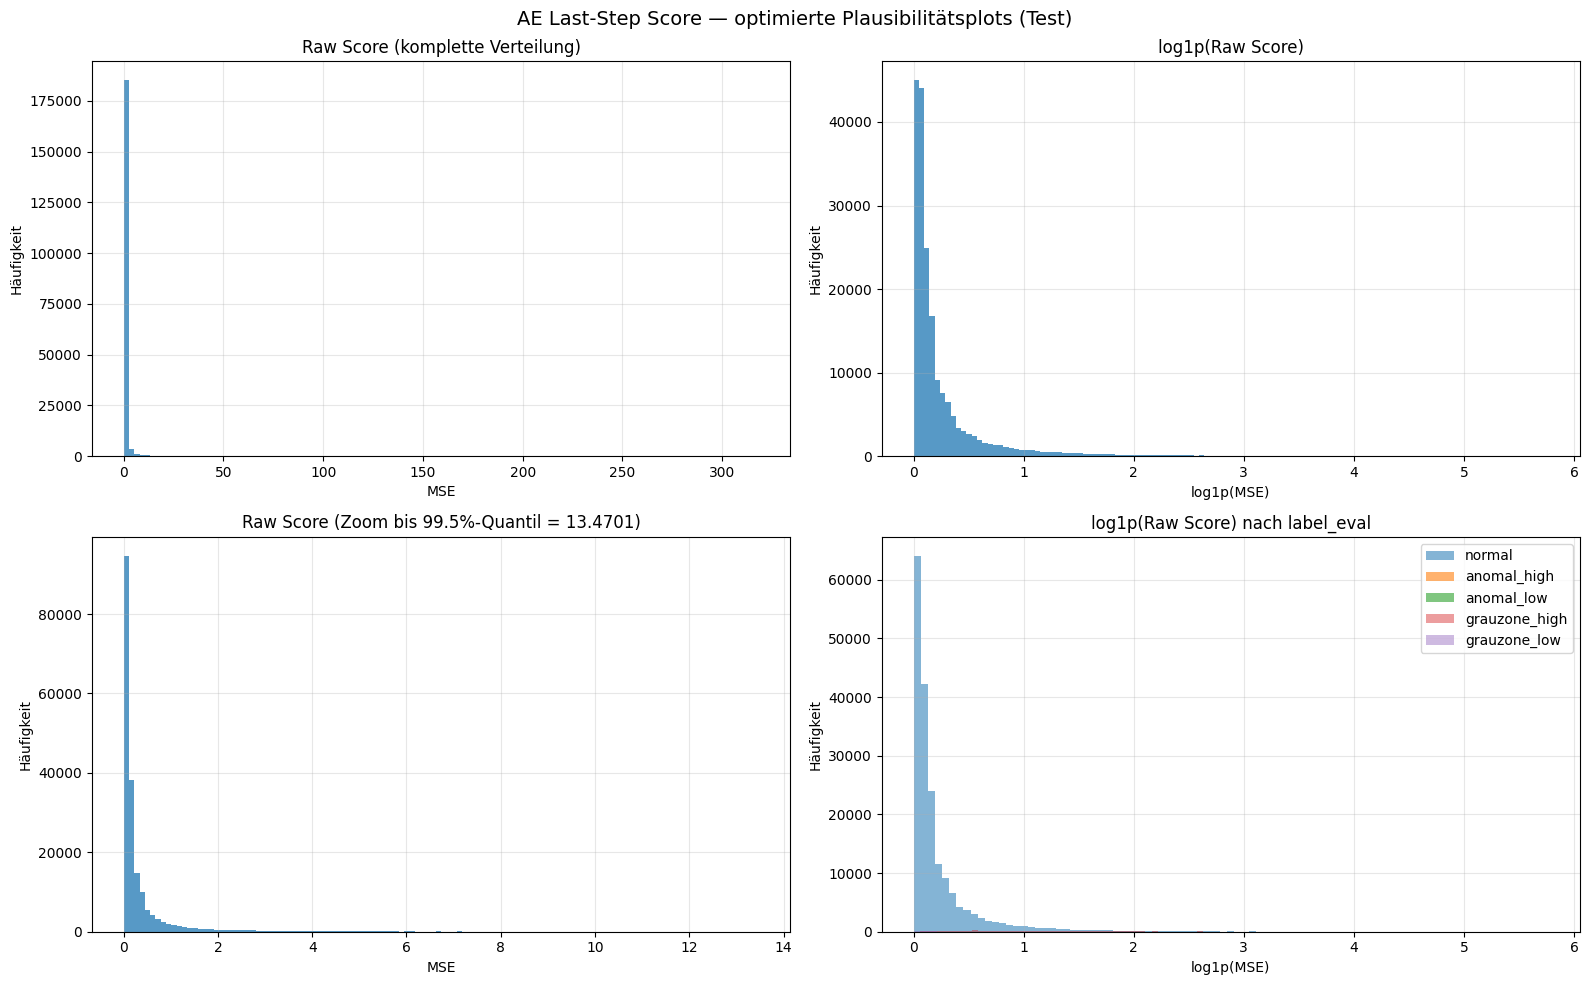

Plot gespeichert: /content/drive/MyDrive/BA_Colab/data/v9_results/checkpoint4_ae_scores_optimized.png


In [47]:
# ══════════════════════════════════════════════════════════════
# AE-Score Plausibilitätsplots (optimiert)
# - log1p-Transformation
# - Quantil-Zoom
# - getrennt nach label_eval
# - speichert PNG
# Voraussetzung:
#   meta_all_seq mit Spalten:
#     - split
#     - ae_last_step_score_raw
#     - label_eval
#   RESULTS_DIR existiert
# ══════════════════════════════════════════════════════════════

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_sub = meta_all_seq[meta_all_seq["split"] == "test"].copy()

if test_sub.empty:
    raise ValueError("test_sub ist leer. Prüfe meta_all_seq['split'].")

score_col = "ae_last_step_score_raw"
label_col = "label_eval"

if score_col not in test_sub.columns:
    raise ValueError(f"{score_col} fehlt in meta_all_seq.")

test_sub = test_sub[np.isfinite(test_sub[score_col])].copy()
if test_sub.empty:
    raise ValueError("Keine endlichen AE-Scores im Testsplit gefunden.")

# Log-Transform für bessere Sichtbarkeit
test_sub["ae_score_log1p"] = np.log1p(test_sub[score_col])

# Quantilgrenzen für Zoom
q95 = test_sub[score_col].quantile(0.95)
q99 = test_sub[score_col].quantile(0.99)
q995 = test_sub[score_col].quantile(0.995)

print("AE-Testscore Quantile:")
print(test_sub[score_col].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999]).round(6))

# Labels, die geplottet werden sollen
plot_labels = ["normal", "anomal_high", "anomal_low", "grauzone_high", "grauzone_low"]
present_labels = [lab for lab in plot_labels if lab in test_sub[label_col].astype(str).unique()]

# Farben nur für Lesbarkeit in den Overlays
label_kwargs = {
    "normal":        {"alpha": 0.55, "label": "normal"},
    "anomal_high":   {"alpha": 0.60, "label": "anomal_high"},
    "anomal_low":    {"alpha": 0.60, "label": "anomal_low"},
    "grauzone_high": {"alpha": 0.45, "label": "grauzone_high"},
    "grauzone_low":  {"alpha": 0.45, "label": "grauzone_low"},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("AE Last-Step Score — optimierte Plausibilitätsplots (Test)", fontsize=14)

# ─────────────────────────────────────────────────────────────
# 1) Rohscore komplett
# ─────────────────────────────────────────────────────────────
axes[0, 0].hist(test_sub[score_col], bins=120, alpha=0.75)
axes[0, 0].set_title("Raw Score (komplette Verteilung)")
axes[0, 0].set_xlabel("MSE")
axes[0, 0].set_ylabel("Häufigkeit")
axes[0, 0].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# 2) log1p(Raw Score) komplett
# ─────────────────────────────────────────────────────────────
axes[0, 1].hist(test_sub["ae_score_log1p"], bins=120, alpha=0.75)
axes[0, 1].set_title("log1p(Raw Score)")
axes[0, 1].set_xlabel("log1p(MSE)")
axes[0, 1].set_ylabel("Häufigkeit")
axes[0, 1].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# 3) Raw Score bis 99.5%-Quantil
# ─────────────────────────────────────────────────────────────
zoom_sub = test_sub[test_sub[score_col] <= q995].copy()
axes[1, 0].hist(zoom_sub[score_col], bins=120, alpha=0.75)
axes[1, 0].set_title(f"Raw Score (Zoom bis 99.5%-Quantil = {q995:.4f})")
axes[1, 0].set_xlabel("MSE")
axes[1, 0].set_ylabel("Häufigkeit")
axes[1, 0].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────
# 4) log1p(Raw Score) nach label_eval
# ─────────────────────────────────────────────────────────────
for lab in present_labels:
    vals = test_sub.loc[test_sub[label_col] == lab, "ae_score_log1p"].dropna()
    if len(vals) == 0:
        continue
    axes[1, 1].hist(vals, bins=80, **label_kwargs.get(lab, {"alpha": 0.5, "label": lab}))

axes[1, 1].set_title("log1p(Raw Score) nach label_eval")
axes[1, 1].set_xlabel("log1p(MSE)")
axes[1, 1].set_ylabel("Häufigkeit")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, "checkpoint4_ae_scores_optimized.png")
plt.show()

print(f"Plot gespeichert: {out_path}")

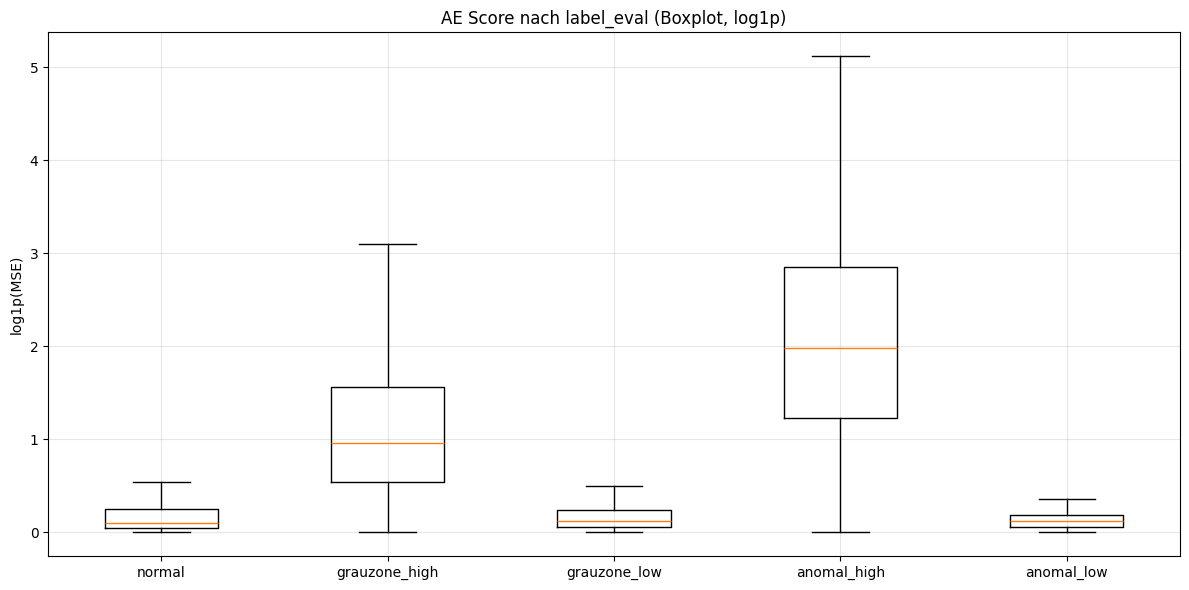

Plot gespeichert: /content/drive/MyDrive/BA_Colab/data/v9_results/checkpoint4_ae_scores_boxplot.png


In [48]:
# ══════════════════════════════════════════════════════════════
# Optional: Boxplot / Quantilvergleich nach label_eval
# ══════════════════════════════════════════════════════════════
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_sub = meta_all_seq[meta_all_seq["split"] == "test"].copy()
test_sub = test_sub[np.isfinite(test_sub["ae_last_step_score_raw"])].copy()
test_sub["ae_score_log1p"] = np.log1p(test_sub["ae_last_step_score_raw"])

order = [lab for lab in ["normal", "grauzone_high", "grauzone_low", "anomal_high", "anomal_low"]
         if lab in test_sub["label_eval"].astype(str).unique()]

if len(order) == 0:
    raise ValueError("Keine passenden label_eval-Werte im Testsplit gefunden.")

data = [
    test_sub.loc[test_sub["label_eval"] == lab, "ae_score_log1p"].dropna().values
    for lab in order
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data, tick_labels=order, showfliers=False)
ax.set_title("AE Score nach label_eval (Boxplot, log1p)")
ax.set_ylabel("log1p(MSE)")
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, "checkpoint4_ae_scores_boxplot.png")
plt.show()

print(f"Plot gespeichert: {out_path}")

--------------

Nochmal Test mit Continues True: Zellen von Oben die ausgeführt sein müssen:

1–4: Imports, Config, Daten laden

5: Aggregationsfunktion

8–12b: Statistikscore-, Poisson-, Kalibrier- und Label-Funktionen

14–20: AE-Features, Sequenzbuilder, AE-Modell, Scoring/Eval

In [31]:
# ══════════════════════════════════════════════════════════════
# GAP TEST 1 — Fehlende Stunden je Station mit 0 auffüllen
#               (robust gegen doppelte station_id-hour_ts)
# ══════════════════════════════════════════════════════════════

def fill_missing_time_bins(
    x: pd.DataFrame,
    minutes: int = 60
) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []

    # Falls station_id + hour_ts mehrfach vorkommt:
    # zuerst auf genau eine Zeile je station_id/hour_ts verdichten.
    x = x.copy().sort_values(["station_id", "hour_ts"])

    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg(
             station_name_id=("station_name_id", "first"),
             station_name=("station_name", "first"),
             location_id=("location_id", "first"),
             latitude=("latitude", "first"),
             longitude=("longitude", "first"),
             n_lends=("n_lends", "sum"),
             n_returns=("n_returns", "sum"),
         )
    )

    # Features neu berechnen
    x["total_demand"] = x["n_lends"] + x["n_returns"]
    x["net_flow"] = x["n_returns"] - x["n_lends"]
    x["abs_net_flow"] = x["net_flow"].abs()

    x["hour"] = x["hour_ts"].dt.hour
    x["dow"] = x["hour_ts"].dt.dayofweek
    x["month"] = x["hour_ts"].dt.month
    x["is_weekend"] = x["dow"].isin([5, 6]).astype(int)

    x["hour_sin"] = np.sin(2 * np.pi * x["hour"] / 24)
    x["hour_cos"] = np.cos(2 * np.pi * x["hour"] / 24)
    x["dow_sin"]  = np.sin(2 * np.pi * x["dow"] / 7)
    x["dow_cos"]  = np.cos(2 * np.pi * x["dow"] / 7)
    x["month_sin"] = np.sin(2 * np.pi * (x["month"] - 1) / 12)
    x["month_cos"] = np.cos(2 * np.pi * (x["month"] - 1) / 12)

    key_cols = [
        "station_id", "station_name_id", "station_name", "location_id",
        "latitude", "longitude"
    ]

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()

        full_idx = pd.date_range(
            start=g["hour_ts"].min(),
            end=g["hour_ts"].max(),
            freq=freq,
            tz=g["hour_ts"].dt.tz
        )

        gi = g.set_index("hour_ts").reindex(full_idx)
        gi.index.name = "hour_ts"
        gi = gi.reset_index()

        for c in key_cols:
            if c in gi.columns:
                gi[c] = gi[c].ffill().bfill()
            else:
                gi[c] = g[c].iloc[0]

        for c in ["n_lends", "n_returns"]:
            gi[c] = gi[c].fillna(0)

        gi["n_lends"] = gi["n_lends"].astype(int)
        gi["n_returns"] = gi["n_returns"].astype(int)

        gi["total_demand"] = gi["n_lends"] + gi["n_returns"]
        gi["net_flow"] = gi["n_returns"] - gi["n_lends"]
        gi["abs_net_flow"] = gi["net_flow"].abs()

        gi["hour"] = gi["hour_ts"].dt.hour
        gi["dow"] = gi["hour_ts"].dt.dayofweek
        gi["month"] = gi["hour_ts"].dt.month
        gi["is_weekend"] = gi["dow"].isin([5, 6]).astype(int)

        gi["hour_sin"] = np.sin(2 * np.pi * gi["hour"] / 24)
        gi["hour_cos"] = np.cos(2 * np.pi * gi["hour"] / 24)
        gi["dow_sin"]  = np.sin(2 * np.pi * gi["dow"] / 7)
        gi["dow_cos"]  = np.cos(2 * np.pi * gi["dow"] / 7)
        gi["month_sin"] = np.sin(2 * np.pi * (gi["month"] - 1) / 12)
        gi["month_cos"] = np.cos(2 * np.pi * (gi["month"] - 1) / 12)

        parts.append(gi)

    out = (
        pd.concat(parts, axis=0)
          .sort_values(["station_id", "hour_ts"])
          .reset_index(drop=True)
    )
    return out

In [32]:
# ══════════════════════════════════════════════════════════════
# GAP TEST 2 — Stundenaggregation + 0er-Fill + aktive Stationen
# ══════════════════════════════════════════════════════════════

df_gap_raw = aggregate_station_level(df_raw, minutes=cfg.aggregation_minutes)

n_before = len(df_gap_raw)
df_gap = fill_missing_time_bins(df_gap_raw, minutes=cfg.aggregation_minutes)
n_after = len(df_gap)

print("Vor Fill:", n_before)
print("Nach Fill:", n_after)
print("Zusätzliche 0-Bins:", n_after - n_before)
print("Anteil neu eingefügter Bins:", round((n_after - n_before) / max(n_after, 1), 4))

# Aktive Stationen wie im Original neu bestimmen
n_days_gap = (df_gap["hour_ts"].max() - df_gap["hour_ts"].min()).days + 1
min_events_gap = int(n_days_gap * cfg.min_events_per_day)

station_volume_gap = df_gap.groupby("station_id")["total_demand"].sum()
active_station_ids_gap = station_volume_gap[station_volume_gap >= min_events_gap].index.tolist()

df_gap = df_gap[df_gap["station_id"].isin(active_station_ids_gap)].copy()
print("Aktive Stationen (gap):", df_gap["station_id"].nunique())

station_profile_gap = (
    df_gap.groupby(["station_id", "station_name"], as_index=False)
      .agg(
          avg_total_demand_h=("total_demand", "mean"),
          avg_lends_h=("n_lends", "mean"),
          avg_returns_h=("n_returns", "mean"),
          latitude=("latitude", "first"),
          longitude=("longitude", "first")
      )
)

q1_gap = station_profile_gap["avg_total_demand_h"].quantile(cfg.low_demand_q)
q2_gap = station_profile_gap["avg_total_demand_h"].quantile(cfg.high_demand_q)

def demand_regime_gap(x):
    if x <= q1_gap:
        return "low"
    elif x <= q2_gap:
        return "mid"
    return "high"

station_profile_gap["demand_regime"] = station_profile_gap["avg_total_demand_h"].apply(demand_regime_gap)

df_gap = df_gap.merge(
    station_profile_gap[["station_id", "demand_regime", "avg_total_demand_h"]],
    on="station_id", how="left"
)

print(station_profile_gap["demand_regime"].value_counts())
display(station_profile_gap.head())

Vor Fill: 1036182
Nach Fill: 2297523
Zusätzliche 0-Bins: 1261341
Anteil neu eingefügter Bins: 0.549
Aktive Stationen (gap): 88
demand_regime
mid     31
high    31
low     31
Name: count, dtype: int64


,station_id,station_name,avg_total_demand_h,avg_lends_h,avg_returns_h,latitude,longitude,demand_regime
0,121376,Lindenhof - Jugendherberge,0.914304,0.457914,0.456390,49.477,8.464,mid
1,142863936,Hauptbahnhof Mannheim 2,4.987071,2.498990,2.488081,49.480,8.471,high
2,148606240,A1 - Landgericht/Universität,2.857309,1.441335,1.415974,49.485,8.463,high
3,1557693,Lindenhof - Johanniskirche,1.028796,0.514157,0.514639,49.474,8.466,mid
4,195402059,Oststadt - Augusta Anlage,0.594353,0.297507,0.296845,49.478,8.490,low


In [33]:
# GAP AE 1 — Splits
t_min_gap = df_gap["hour_ts"].min()
t_max_gap = df_gap["hour_ts"].max()
total_h_gap = (t_max_gap - t_min_gap).total_seconds() / 3600

train_end_gap = t_min_gap + pd.Timedelta(hours=int(total_h_gap * cfg.train_ratio))
val_end_gap   = t_min_gap + pd.Timedelta(hours=int(total_h_gap * cfg.val_ratio))

print("df_gap shape:", df_gap.shape)
print("train_end_gap:", train_end_gap)
print("val_end_gap:  ", val_end_gap)

df_gap shape: (2207450, 24)
train_end_gap: 2025-02-25 02:00:00+00:00
val_end_gap:   2025-07-30 22:00:00+00:00


In [34]:
# GAP AE 2 — AE-Daten vorbereiten
df_ae_gap = df_gap.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
df_ae_gap = df_ae_gap.dropna(subset=AE_FEATURES).copy()

print(f"AE-Daten gap: {df_ae_gap.shape}")
print(f"AE-Features ({len(AE_FEATURES)}): {AE_FEATURES}")

scaler_gap = StandardScaler()
train_mask_ae_gap = df_ae_gap["hour_ts"] < train_end_gap

scaler_gap.fit(df_ae_gap.loc[train_mask_ae_gap, AE_FEATURES])

df_ae_gap_scaled = df_ae_gap.copy()
df_ae_gap_scaled[AE_FEATURES] = scaler_gap.transform(df_ae_gap[AE_FEATURES])

print("Scaler fitted on train only.")
print(f"Train-Zeilen für Scaler: {train_mask_ae_gap.sum():,}")

AE-Daten gap: (2207450, 24)
AE-Features (9): ['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
Scaler fitted on train only.
Train-Zeilen für Scaler: 1,458,722


In [35]:
# GAP AE 3 — Sequenzen ohne Labels, aber contiguous=True
X_all_gap, meta_all_gap, y_all_gap = make_sequences_fast(
    df_ae_gap_scaled,
    feature_cols=AE_FEATURES,
    window_size=cfg.ae_window_size,
    label_col=None,
    require_contiguous=True,
    agg_minutes=cfg.aggregation_minutes
)

print("Sequenzen gesamt:", X_all_gap.shape)
print("Meta gesamt:", meta_all_gap.shape)
print("y_all_gap:", y_all_gap)

meta_all_gap["split"] = np.where(
    meta_all_gap["hour_ts"] < train_end_gap, "train",
    np.where(meta_all_gap["hour_ts"] < val_end_gap, "val", "test")
)

train_seq_mask_gap = meta_all_gap["split"] == "train"
val_seq_mask_gap   = meta_all_gap["split"] == "val"
test_seq_mask_gap  = meta_all_gap["split"] == "test"

X_train_gap = X_all_gap[train_seq_mask_gap.values]
X_val_gap   = X_all_gap[val_seq_mask_gap.values]
X_test_gap  = X_all_gap[test_seq_mask_gap.values]

meta_train_gap = meta_all_gap.loc[train_seq_mask_gap].reset_index(drop=True)
meta_val_gap   = meta_all_gap.loc[val_seq_mask_gap].reset_index(drop=True)
meta_test_gap  = meta_all_gap.loc[test_seq_mask_gap].reset_index(drop=True)

print(f"X_train_gap: {X_train_gap.shape}")
print(f"X_val_gap:   {X_val_gap.shape}")
print(f"X_test_gap:  {X_test_gap.shape}")

Sequenzen gesamt: (1981139, 24, 9)
Meta gesamt: (1981139, 24)
y_all_gap: None
X_train_gap: (1306467, 24, 9)
X_val_gap:   (306680, 24, 9)
X_test_gap:  (367992, 24, 9)


In [36]:
# ══════════════════════════════════════════════════════════════
# GAP TEST 4 — Thresholds
# ══════════════════════════════════════════════════════════════

pct_cols_gap = [c for c in df_gap.columns if c.endswith("_pct_station")]
print("Anzahl pct-Spalten (gap):", len(pct_cols_gap))

for col in pct_cols_gap:
    tmp_station = (
        df_gap[df_gap["hour_ts"] < train_end_gap]
        .groupby("station_id")[col]
        .quantile(cfg.threshold_quantile_station)
        .reset_index()
        .rename(columns={col: f"{col}_thr_station"})
    )

    tmp_regime = (
        df_gap[df_gap["hour_ts"] < train_end_gap]
        .groupby("demand_regime")[col]
        .quantile(cfg.threshold_quantile_group)
        .reset_index()
        .rename(columns={col: f"{col}_thr_regime"})
    )

    df_gap = df_gap.merge(tmp_station, on="station_id", how="left")
    df_gap = df_gap.merge(tmp_regime, on="demand_regime", how="left")

    df_gap[f"{col}_pred_station"] = (df_gap[col] >= df_gap[f"{col}_thr_station"]).astype(int)
    df_gap[f"{col}_pred_regime"]  = (df_gap[col] >= df_gap[f"{col}_thr_regime"]).astype(int)

print("Threshold-Zellen gebaut.")

Anzahl pct-Spalten (gap): 0
Threshold-Zellen gebaut.


In [37]:
# GAP AE 4 — Modell bauen und trainieren
ae_model_gap = build_lstm_autoencoder(
    n_features=len(AE_FEATURES),
    window_size=cfg.ae_window_size,
    latent_dim=cfg.ae_latent_dim,
    n_layers=cfg.ae_layers,
    dropout=cfg.ae_dropout
)

ae_model_gap.summary()

ae_model_gap, ae_history_gap = train_autoencoder(
    ae_model_gap,
    X_train=X_train_gap,
    X_val=X_val_gap,
    cfg=cfg
)

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 0.5249 - val_loss: 0.1548 - learning_rate: 0.0010
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1961 - val_loss: 0.1266 - learning_rate: 0.0010
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1665 - val_loss: 0.1167 - learning_rate: 0.0010
Epoch 4/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1549 - val_loss: 0.1095 - learning_rate: 0.0010
Epoch 5/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1473 - val_loss: 0.1045 - learning_rate: 0.0010
Epoch 6/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1414 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 7/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1371 - val_loss: 0.0997 - learning_rate: 0.0010
Epoch 8/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1336 - val_loss: 0.0977 - learning_rate: 0.0010
Epoch 9/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1302 - val_loss: 0.0963 - learning_rate:

In [40]:
# GAP AE helper — Last-step scoring definieren

AE_SCORE_FEATURES = ["n_lends", "n_returns"]
ae_score_idx = [AE_FEATURES.index(c) for c in AE_SCORE_FEATURES]

def ae_last_step_scores(model: keras.Model, X: np.ndarray, batch_size: int = 2048) -> np.ndarray:
    """
    Last-step reconstruction error nur auf den Demand-Kernfeatures,
    die tatsächlich im AE-Input enthalten sind.
    """
    scores = []

    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size]
        x_hat = model.predict(xb, verbose=0)

        err = (x_hat[:, -1, ae_score_idx] - xb[:, -1, ae_score_idx]) ** 2
        score = err.mean(axis=1)
        scores.append(score)

    return np.concatenate(scores) if scores else np.array([])

In [41]:
# GAP AE 5 — Raw Scores
ae_train_scores_gap = ae_last_step_scores(ae_model_gap, X_train_gap)
ae_val_scores_gap   = ae_last_step_scores(ae_model_gap, X_val_gap)
ae_test_scores_gap  = ae_last_step_scores(ae_model_gap, X_test_gap)

meta_train_gap = meta_train_gap.copy()
meta_val_gap   = meta_val_gap.copy()
meta_test_gap  = meta_test_gap.copy()

meta_train_gap["ae_last_step_score_raw"] = ae_train_scores_gap
meta_val_gap["ae_last_step_score_raw"]   = ae_val_scores_gap
meta_test_gap["ae_last_step_score_raw"]  = ae_test_scores_gap

print("AE Score Summary")
print("Train:")
print(meta_train_gap["ae_last_step_score_raw"].describe().round(6))
print("\nVal:")
print(meta_val_gap["ae_last_step_score_raw"].describe().round(6))
print("\nTest:")
print(meta_test_gap["ae_last_step_score_raw"].describe().round(6))

AE Score Summary
Train:
count    1.306467e+06
mean     3.027200e-01
std      1.703216e+00
min      0.000000e+00
25%      5.673000e-03
50%      5.183400e-02
75%      1.828450e-01
max      4.479235e+02
Name: ae_last_step_score_raw, dtype: float64

Val:
count    306680.000000
mean          0.351983
std           1.629723
min           0.000000
25%           0.008112
50%           0.064713
75%           0.233727
max         222.774094
Name: ae_last_step_score_raw, dtype: float64

Test:
count    367992.000000
mean          0.277922
std           1.810021
min           0.000000
25%           0.004639
50%           0.041774
75%           0.145379
max         451.623596
Name: ae_last_step_score_raw, dtype: float64


In [42]:
# GAP AE 6 — stationsspezifische Percentile-Kalibrierung

def percentile_score(train_vals: np.ndarray, vals: np.ndarray) -> np.ndarray:
    train_vals = np.asarray(train_vals, dtype=float)
    vals = np.asarray(vals, dtype=float)

    train_vals = train_vals[np.isfinite(train_vals)]
    out = np.full(len(vals), np.nan, dtype=float)

    if len(train_vals) == 0:
        return out

    train_vals = np.sort(train_vals)
    ranks = np.searchsorted(train_vals, vals, side="right")
    return ranks / len(train_vals)

meta_all_seq_gap = pd.concat([meta_train_gap, meta_val_gap, meta_test_gap], axis=0).reset_index(drop=True)
meta_all_seq_gap["ae_last_step_score_pct_station"] = np.nan

for sid, grp in meta_all_seq_gap.groupby("station_id", sort=False):
    idx_all = grp.index
    idx_train = grp.index[grp["hour_ts"] < train_end_gap]

    train_vals = meta_all_seq_gap.loc[idx_train, "ae_last_step_score_raw"].to_numpy(dtype=float)
    vals = meta_all_seq_gap.loc[idx_all, "ae_last_step_score_raw"].to_numpy(dtype=float)

    meta_all_seq_gap.loc[idx_all, "ae_last_step_score_pct_station"] = percentile_score(train_vals, vals)

ae_thr_station_gap = (
    meta_all_seq_gap[meta_all_seq_gap["hour_ts"] < train_end_gap]
    .groupby("station_id")["ae_last_step_score_pct_station"]
    .quantile(cfg.threshold_quantile_station)
    .reset_index()
    .rename(columns={"ae_last_step_score_pct_station": "ae_last_step_thr_station"})
)

meta_all_seq_gap = meta_all_seq_gap.merge(ae_thr_station_gap, on="station_id", how="left")
meta_all_seq_gap["ae_pred_station"] = (
    meta_all_seq_gap["ae_last_step_score_pct_station"] >= meta_all_seq_gap["ae_last_step_thr_station"]
).astype(int)

print(meta_all_seq_gap[["ae_last_step_score_raw", "ae_last_step_score_pct_station", "ae_pred_station"]].describe().round(6))

       ae_last_step_score_raw  ae_last_step_score_pct_station  ae_pred_station
count            1.981139e+06                    1.981139e+06     1.981139e+06
mean             3.057400e-01                    5.050270e-01     5.513000e-03
std              1.706896e+00                    2.892600e-01     7.404500e-02
min              0.000000e+00                    0.000000e+00     0.000000e+00
25%              5.740000e-03                    2.546150e-01     0.000000e+00
50%              5.220400e-02                    5.071040e-01     0.000000e+00
75%              1.839000e-01                    7.567730e-01     0.000000e+00
max              4.516236e+02                    1.000000e+00     1.000000e+00


In [43]:
print("Pred rate train:",
      meta_all_seq_gap.loc[meta_all_seq_gap["hour_ts"] < train_end_gap, "ae_pred_station"].mean().round(4))

print("Pred rate val:",
      meta_all_seq_gap.loc[
          (meta_all_seq_gap["hour_ts"] >= train_end_gap) &
          (meta_all_seq_gap["hour_ts"] < val_end_gap),
          "ae_pred_station"
      ].mean().round(4))

print("Pred rate test:",
      meta_all_seq_gap.loc[
          meta_all_seq_gap["hour_ts"] >= val_end_gap,
          "ae_pred_station"
      ].mean().round(4))

print("\nPct summary train:")
print(meta_all_seq_gap.loc[
    meta_all_seq_gap["hour_ts"] < train_end_gap,
    "ae_last_step_score_pct_station"
].describe().round(6))

print("\nPct summary val:")
print(meta_all_seq_gap.loc[
    (meta_all_seq_gap["hour_ts"] >= train_end_gap) &
    (meta_all_seq_gap["hour_ts"] < val_end_gap),
    "ae_last_step_score_pct_station"
].describe().round(6))

print("\nPct summary test:")
print(meta_all_seq_gap.loc[
    meta_all_seq_gap["hour_ts"] >= val_end_gap,
    "ae_last_step_score_pct_station"
].describe().round(6))

Pred rate train: 0.005
Pred rate val: 0.0079
Pred rate test: 0.0052

Pct summary train:
count    1.306467e+06
mean     5.000340e-01
std      2.886750e-01
min      6.000000e-05
25%      2.500450e-01
50%      5.000300e-01
75%      7.500300e-01
max      1.000000e+00
Name: ae_last_step_score_pct_station, dtype: float64

Pct summary val:
count    306680.000000
mean          0.548101
std           0.285544
min           0.000000
25%           0.307190
50%           0.569759
75%           0.800084
max           1.000000
Name: ae_last_step_score_pct_station, dtype: float64

Pct summary test:
count    367992.000000
mean          0.486857
std           0.291012
min           0.000000
25%           0.232119
50%           0.479905
75%           0.738072
max           1.000000
Name: ae_last_step_score_pct_station, dtype: float64


In [44]:
# GAP AE 7 — Evaluation gegen alte label_eval aus dem alten Lauf

if "df" not in globals():
    raise ValueError("Altes df aus dem ursprünglichen Lauf ist nicht in der Session vorhanden.")

if "label_eval" not in df.columns:
    raise ValueError("Im alten df gibt es keine Spalte 'label_eval'.")

eval_gap = meta_all_seq_gap.merge(
    df[["station_id", "hour_ts", "label_eval"]].drop_duplicates(["station_id", "hour_ts"]),
    on=["station_id", "hour_ts"],
    how="left"
)

print("Gemergte Sequenzen:", len(eval_gap))
print("Fehlende label_eval:", eval_gap["label_eval"].isna().sum())

# Beispiel 1: anomal_high als positives Label
eval_gap["y_true_high"] = (eval_gap["label_eval"] == "anomal_high").astype(int)

for split_name in ["train", "val", "test"]:
    sub = eval_gap[eval_gap["split"] == split_name].copy()
    if len(sub) == 0:
        continue

    y_true = sub["y_true_high"].values
    y_score = sub["ae_last_step_score_pct_station"].values
    y_pred = sub["ae_pred_station"].values

    print(f"\n=== {split_name.upper()} | anomal_high ===")
    print("n =", len(sub))
    print("Positive Rate true:", y_true.mean().round(4))
    print("Positive Rate pred:", y_pred.mean().round(4))

    if len(np.unique(y_true)) > 1:
        print("ROC-AUC:", round(roc_auc_score(y_true, y_score), 4))
        print("PR-AUC: ", round(average_precision_score(y_true, y_score), 4))
        print("F1:     ", round(f1_score(y_true, y_pred, zero_division=0), 4))
    else:
        print("Nur eine Klasse in y_true vorhanden.")

Gemergte Sequenzen: 1981139
Fehlende label_eval: 1023775

=== TRAIN | anomal_high ===
n = 1306467
Positive Rate true: 0.0016
Positive Rate pred: 0.005
ROC-AUC: 0.9843
PR-AUC:  0.3732
F1:      0.3083

=== VAL | anomal_high ===
n = 306680
Positive Rate true: 0.0025
Positive Rate pred: 0.0079
ROC-AUC: 0.9781
PR-AUC:  0.3796
F1:      0.3164

=== TEST | anomal_high ===
n = 367992
Positive Rate true: 0.0015
Positive Rate pred: 0.0052
ROC-AUC: 0.992
PR-AUC:  0.4248
F1:      0.3206


In [45]:
eval_gap["y_true_any"] = eval_gap["label_eval"].isin(["anomal_high", "anomal_low"]).astype(int)

for split_name in ["train", "val", "test"]:
    sub = eval_gap[eval_gap["split"] == split_name].copy()
    if len(sub) == 0:
        continue

    y_true = sub["y_true_any"].values
    y_score = sub["ae_last_step_score_pct_station"].values
    y_pred = sub["ae_pred_station"].values

    print(f"\n=== {split_name.upper()} | any anomaly ===")
    print("n =", len(sub))
    print("Positive Rate true:", y_true.mean().round(4))
    print("Positive Rate pred:", y_pred.mean().round(4))

    if len(np.unique(y_true)) > 1:
        print("ROC-AUC:", round(roc_auc_score(y_true, y_score), 4))
        print("PR-AUC: ", round(average_precision_score(y_true, y_score), 4))
        print("F1:     ", round(f1_score(y_true, y_pred, zero_division=0), 4))
    else:
        print("Nur eine Klasse in y_true vorhanden.")


=== TRAIN | any anomaly ===
n = 1306467
Positive Rate true: 0.0017
Positive Rate pred: 0.005
ROC-AUC: 0.9535
PR-AUC:  0.3409
F1:      0.3014

=== VAL | any anomaly ===
n = 306680
Positive Rate true: 0.0027
Positive Rate pred: 0.0079
ROC-AUC: 0.9573
PR-AUC:  0.3535
F1:      0.3108

=== TEST | any anomaly ===
n = 367992
Positive Rate true: 0.0017
Positive Rate pred: 0.0052
ROC-AUC: 0.9497
PR-AUC:  0.3704
F1:      0.31
